# F_S1.1 — Redesigned Parameter-Diverse Dataset

Redesigned signal generation from E_S1, with the core principle:
**every family must be visually recognizable at all strength levels, including very_weak.**

Key changes from E:

- F03/F05: raised minimum curvature so very_weak is visibly non-linear.
- F07: raised minimum k so saturation plateau is always visible.
- F13: raised minimum steepness so S-shape is always visible.
- F15: narrowed transition band so threshold step is always visible.
- F18: standalone canonical, pure vertex-form parabola (F17 removed).
- F21: removed additive x, pure cubic polynomial.
- F22: removed subtype system, pure sine oscillation.
- F23: raised minimum separation so two branches are always distinguishable.
- F25: rewritten as clean multi-level sigmoid staircase.
- F26: rewritten as Gaussian bumps (localized response windows).

Three orthogonal axes preserved: family×strength, SNR, x-distribution.


In [82]:
from __future__ import annotations

import json
import math
import os
import time
from dataclasses import asdict, dataclass
from itertools import combinations
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd

os.environ.setdefault('MPLCONFIGDIR', str(Path('.matplotlib').resolve()))
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)

# MODE is set in the first code cell so this notebook can be run directly.
MODE = 'full'
if MODE not in {'design', 'full'}:
    raise ValueError(f'Unknown MODE={MODE!r}; expected design or full.')
REUSE_EXISTING = os.environ.get('PARAM_FUZZY_REUSE', '0').strip() == '1'
WRITE_DESIGN_TABLES = MODE == 'full'
WRITE_CASE_TABLE = MODE == 'full'
WRITE_SCATTER_POINTS = MODE == 'full' and not REUSE_EXISTING

# When False, each family uses a single midpoint parameter set (u=0.5,0.5,0.5)
# instead of 8 diverse nuisance groups. Variation comes from family x strength x SNR.
USE_NUISANCE_GROUPS = True
N_GROUPS = 8 if USE_NUISANCE_GROUPS else 1

# Representative families: one canonical form per shape category.
# All 25 signal families are still generated; this tag is for filtering/analysis.
REPRESENTATIVE_FAMILIES = [
    'F01', 'F03', 'F05', 'F07', 'F13', 'F15',
    'F18', 'F21', 'F22', 'F23', 'F25', 'F26', 'Null',
]

def locate_repo_root() -> Path:
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for root in candidates:
        if (root / 'D').is_dir() and (root / 'E').is_dir():
            return root
    raise FileNotFoundError('Could not locate the sythetic repository root containing D/ and E/.')


REPO_ROOT = locate_repo_root()
E_DIR = REPO_ROOT / 'F'
OUTPUT_ROOT = E_DIR / 'output' / 'S1_parameterized'
OUTPUT_DIR = OUTPUT_ROOT
LABELS_PATH = OUTPUT_DIR / 'case_visual_labels.csv'

RANDOM_SEED = 20260717
N_PER_CASE = 500
N_REPLICATES = 5

STRENGTH_NAMES = ['very_weak', 'weak', 'medium', 'strong', 'very_strong']

# Keep this SNR construction identical to E_S1_snr_sweep_generation.ipynb.
E_S1_ORIGINAL_SNR = sorted(
    np.geomspace(0.001, 500, 200).tolist()
    + [750.0, 1000.0, 2000.0, 5000.0, 10000.0]
) + [math.inf]
E_S1_HIGH_INVERSE_SNR = np.linspace(0.0, 0.01, 22)[1:-1]
E_S1_ADDED_HIGH_SNR = (1.0 / E_S1_HIGH_INVERSE_SNR).tolist()
E_S1_FINITE_SNR = sorted(
    set(float(value) for value in E_S1_ORIGINAL_SNR if np.isfinite(value))
    | {100.0}
    | set(E_S1_ADDED_HIGH_SNR)
)
SNR_GRID_FULL = E_S1_FINITE_SNR + [math.inf]

assert len(E_S1_ORIGINAL_SNR) == 206
assert len(E_S1_ADDED_HIGH_SNR) == 20
assert len(SNR_GRID_FULL) == 227
assert SNR_GRID_FULL[0] == 0.001
assert SNR_GRID_FULL[-2] == 10000.0
assert SNR_GRID_FULL[-1] == math.inf

n_signal_base = 25 * 5 * N_GROUPS
n_null_base = N_GROUPS
print(f'Mode: {MODE}  |  USE_NUISANCE_GROUPS: {USE_NUISANCE_GROUPS}')
print(f'Design: 25 families x 5 strengths x {N_GROUPS} group(s) = {n_signal_base:,} signal + {n_null_base} Null = {n_signal_base + n_null_base} base functions')
print(f'Total cases (full): {(n_signal_base + n_null_base) * len(SNR_GRID_FULL) * N_REPLICATES:,}')
print(f'Representative families: {REPRESENTATIVE_FAMILIES}')

Mode: full  |  USE_NUISANCE_GROUPS: True
Design: 25 families x 5 strengths x 8 group(s) = 1,000 signal + 8 Null = 1008 base functions
Total cases (full): 1,144,080
Representative families: ['F01', 'F03', 'F05', 'F07', 'F13', 'F15', 'F18', 'F21', 'F22', 'F23', 'F25', 'F26', 'Null']


## 1. Family catalogue and paired directions

Positive/negative counterparts share the same nuisance groups and split assignment. This prevents direction from being confounded with parameter choice.

In [83]:
FAMILY_NAMES = {
    'F01': 'Linear positive', 'F02': 'Linear negative',
    'F03': 'Power convex positive', 'F04': 'Power convex negative',
    'F05': 'Power concave positive', 'F06': 'Power concave negative',
    'F07': 'Saturation positive', 'F08': 'Saturation negative',
    'F09': 'Log positive', 'F10': 'Log negative',
    'F11': 'Exponential positive', 'F12': 'Exponential negative',
    'F13': 'S-curve positive', 'F14': 'S-curve negative',
    'F15': 'Threshold positive', 'F16': 'Threshold negative',
    'F18': 'Quadratic valley',
    'F19': 'Spike', 'F20': 'Inverted spike',
    'F21': 'Cubic', 'F22': 'Oscillation',
    'F23': 'Two lines', 'F24': 'Line and parabola',
    'F25': 'Multi-regime threshold', 'F26': 'Windowed threshold',
    'Null': 'No relationship',
}

PAIR_CANONICAL = {
    'F02': 'F01', 'F04': 'F03', 'F06': 'F05', 'F08': 'F07',
    'F10': 'F09', 'F12': 'F11', 'F14': 'F13', 'F16': 'F15',
    'F20': 'F19',
}
CANONICAL_FAMILIES = [fid for fid in FAMILY_NAMES if fid != 'Null' and fid not in PAIR_CANONICAL]
SIGNAL_FAMILIES = sorted(FAMILY_NAMES.keys() - {'Null'}, key=lambda x: int(x[1:]))
MULTI_BRANCH_FAMILIES = {'F23', 'F24', 'F25'}

family_catalogue = pd.DataFrame({
    'family_id': SIGNAL_FAMILIES,
    'family_name': [FAMILY_NAMES[fid] for fid in SIGNAL_FAMILIES],
    'canonical_family': [PAIR_CANONICAL.get(fid, fid) for fid in SIGNAL_FAMILIES],
})
display(family_catalogue)


,family_id,family_name,canonical_family
0,F01,Linear positive,F01
1,F02,Linear negative,F01
2,F03,Power convex positive,F03
3,F04,Power convex negative,F03
4,F05,Power concave positive,F05
5,F06,Power concave negative,F05
6,F07,Saturation positive,F07
7,F08,Saturation negative,F07
8,F09,Log positive,F09
9,F10,Log negative,F09


## 2. Parameterized signal functions

Each family has a primary strength axis plus three continuous nuisance coordinates `u1/u2/u3`. The coordinates are mapped to family-specific parameters. The eight retained nuisance groups are selected from 48 Latin-hypercube candidates by maximin distance over parameters and clean curve signatures.

For one-parameter invariant families such as exact lines, nuisance parameters mainly test robustness; they are not interpreted as different degrees of linearity.

In [84]:
def lerp(lo: float, hi: float, u: float) -> float:
    return float(lo + (hi - lo) * u)


def build_params(fid: str, strength_index: int, u: np.ndarray) -> dict[str, Any]:
    canonical = PAIR_CANONICAL.get(fid, fid)
    u1, u2, u3 = map(float, u)

    if canonical == 'F01':
        slopes = [0.25, 0.5, 1.0, 2.0, 4.0]
        return {'slope': slopes[strength_index], 'intercept': lerp(-0.5, 0.5, u1),
                'x_offset': lerp(0.0, 0.15, u2), 'x_scale': lerp(0.8, 1.2, u3)}
    if canonical == 'F03':
        powers = [1.3, 1.6, 2.0, 3.0, 4.5]
        return {'p': powers[strength_index], 'h': lerp(0.0, 0.25, u1),
                'x_scale': lerp(0.8, 1.2, u2), 'amplitude': lerp(0.8, 1.2, u3)}
    if canonical == 'F05':
        powers = [0.55, 0.40, 0.30, 0.20, 0.10]
        return {'p': powers[strength_index], 'h': lerp(0.0, 0.18, u1),
                'x_scale': lerp(0.8, 1.2, u2), 'amplitude': lerp(0.8, 1.2, u3)}
    if canonical == 'F07':
        rates = [3.0, 5.0, 8.0, 14.0, 25.0]
        return {'k': rates[strength_index],
                'x_scale': lerp(0.8, 1.2, u1), 'amplitude': lerp(0.8, 1.2, u2),
                'y_shift': lerp(-0.05, 0.05, u3)}
    if canonical == 'F09':
        scales = [0.5, 1.5, 5.0, 20.0, 80.0]
        return {'a': scales[strength_index], 'h': lerp(0.0, 0.2, u1),
                'x_scale': lerp(0.8, 1.2, u2), 'amplitude': lerp(0.8, 1.2, u3)}
    if canonical == 'F11':
        rates = [0.2, 0.5, 1.0, 2.0, 4.0]
        return {'rate': rates[strength_index], 'x_offset': lerp(0.0, 0.12, u1),
                'x_scale': lerp(0.8, 1.2, u2), 'amplitude': lerp(0.8, 1.2, u3)}
    if canonical == 'F13':
        steepness = [4.0, 6.0, 10.0, 16.0, 25.0]
        return {'k': steepness[strength_index], 'c': lerp(0.3, 0.7, u1),
                'nu': lerp(0.85, 1.15, u2), 'amplitude': lerp(0.8, 1.2, u3)}
    if canonical == 'F15':
        widths = [0.15, 0.10, 0.06, 0.03, 0.01]
        return {'delta': widths[strength_index], 'c': lerp(0.3, 0.7, u1),
                'gap': lerp(0.7, 1.3, u2), 'baseline': lerp(-0.2, 0.2, u3)}
    if canonical == 'F18':
        curvatures = [1.0, 2.5, 5.0, 8.0, 12.0]
        return {'a': curvatures[strength_index],
                'c': lerp(0.3, 0.7, u1),
                'd': lerp(-0.1, 0.1, u2),
                'amplitude': lerp(0.4, 1.6, u3)}
    if canonical == 'F19':
        widths = [0.10, 0.08, 0.06, 0.05, 0.03]
        return {'width': widths[strength_index], 'c': lerp(0.3, 0.7, u1),
                'amplitude': lerp(0.8, 1.2, u2), 'baseline': lerp(-0.1, 0.1, u3)}
    if canonical == 'F21':
        amplitudes = [8.0, 14.0, 22.0, 30.0, 50.0]
        return {'a': amplitudes[strength_index],
                'roots_center': lerp(0.4, 0.6, u1),
                'roots_spacing': lerp(0.20, 0.30, u2),
                'orientation': -1.0 if u3 < 0.5 else 1.0}
    if canonical == 'F22':
        cycles = [1.0, 1.5, 2.0, 3.0, 5.0]
        return {'cycles': cycles[strength_index],
                'phase': lerp(0.0, math.pi / 2, u1),
                'amplitude': lerp(0.8, 1.2, u2),
                'freq_mod': lerp(0.9, 1.1, u3)}
    if canonical == 'F23':
        separation = [0.6, 1.0, 1.5, 2.5, 4.0]
        return {'separation': separation[strength_index],
                'base_slope': lerp(0.3, 0.8, u1),
                'intercept_gap': lerp(0.0, 0.4, u2),
                'mix_prob': lerp(0.35, 0.65, u3)}
    if canonical == 'F24':
        curvature = [0.3, 0.7, 1.2, 2.0, 3.5]
        return {'a_para': curvature[strength_index], 'm': lerp(0.8, 3.0, u1),
                'h': lerp(0.3, 0.7, u2), 'mix_prob': lerp(0.3, 0.7, u3), 'peak': 0.5}
    if canonical == 'F25':
        # Overlapping multi-regime: branch positions fixed (from D), strength
        # scales height and steepness together.  Nuisance shifts positions.
        height_scales = [0.4, 0.7, 1.0, 1.5, 2.0]
        steep_scales  = [0.6, 0.8, 1.0, 1.3, 1.6]
        hs = height_scales[strength_index]
        ss = steep_scales[strength_index]
        shift = lerp(-0.03, 0.03, u1)
        h_var = lerp(0.8, 1.2, u2)
        s_var = lerp(0.8, 1.2, u3)
        base_branches = [
            (0.00 + shift, 0.30 + shift, hs * h_var * 1.0, ss * s_var * 5.0),
            (0.20 + shift, 0.48 + shift, hs * h_var * 1.6, ss * s_var * 5.0),
            (0.38 + shift, 0.68 + shift, hs * h_var * 0.8, ss * s_var * 6.0),
            (0.60 + shift, 1.00 + shift, hs * h_var * 1.3, ss * s_var * 5.0),
        ]
        return {'branches': base_branches}
    if canonical == 'F26':
        # Windowed J: each window has its own steepness (from D).  Strength
        # scales heights and steepnesses together.
        height_scales = [0.4, 0.7, 1.0, 1.5, 2.0]
        steep_scales  = [0.5, 0.7, 1.0, 1.3, 1.6]
        hs = height_scales[strength_index]
        ss = steep_scales[strength_index]
        shift = lerp(-0.03, 0.03, u1)
        w_scale = lerp(0.75, 1.25, u2)
        h_var = lerp(0.8, 1.2, u3)
        base_windows = [
            (0.12 + shift, 0.12 * w_scale, hs * h_var * 1.0, ss * 6.0),
            (0.36 + shift, 0.14 * w_scale, hs * h_var * 1.6, ss * 5.0),
            (0.60 + shift, 0.12 * w_scale, hs * h_var * 0.7, ss * 8.0),
            (0.84 + shift, 0.10 * w_scale, hs * h_var * 1.3, ss * 5.0),
        ]
        return {'windows': base_windows}
    raise ValueError(f'No parameter builder for {fid}')


def _triangular_local(x: np.ndarray, center: float, width: float) -> np.ndarray:
    return np.maximum(0.0, 1.0 - np.abs(x - center) / max(width, 1e-6))


def evaluate_signal(x: np.ndarray, fid: str, params: dict[str, Any],
                    rng: np.random.Generator | None = None) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    canonical = PAIR_CANONICAL.get(fid, fid)
    sign = -1.0 if fid in {'F02', 'F04', 'F06', 'F08', 'F10', 'F12', 'F14', 'F16'} else 1.0
    p = params

    if canonical == 'F01':
        xe = p['x_offset'] + p['x_scale'] * x
        return sign * (p['slope'] * xe + p['intercept'])

    if canonical in {'F03', 'F05'}:
        xe = np.maximum(p['x_scale'] * x + p['h'], 1e-8)
        y = p['amplitude'] * (xe ** p['p'] - p['h'] ** p['p'])
        return sign * y

    if canonical == 'F07':
        z = p['x_scale'] * x
        return sign * (p['amplitude'] * (1.0 - np.exp(-p['k'] * z)) + p['y_shift'])

    if canonical == 'F09':
        xe = np.maximum(p['x_scale'] * x + p['h'], 0.0)
        y = p['amplitude'] * (np.log1p(p['a'] * xe) - np.log1p(p['a'] * p['h']))
        return sign * y

    if canonical == 'F11':
        xe = p['x_offset'] + p['x_scale'] * x
        y = p['amplitude'] * (np.exp(p['rate'] * xe) - np.exp(p['rate'] * p['x_offset']))
        return sign * y

    if canonical == 'F13':
        logistic = (1.0 + np.exp(-p['k'] * (x - p['c']))) ** (-p['nu'])
        return sign * p['amplitude'] * logistic

    if canonical == 'F15':
        t = np.clip((x - (p['c'] - p['delta'])) / (2.0 * p['delta']), 0.0, 1.0)
        return sign * (p['baseline'] + p['gap'] * t)

    if canonical == 'F18':
        return p['amplitude'] * p['a'] * (x - p['c']) ** 2 + p['d']

    if canonical == 'F19':
        spike = p['amplitude'] * _triangular_local(x, p['c'], p['width'])
        return p['baseline'] + spike if fid == 'F19' else p['baseline'] + p['amplitude'] - spike

    if canonical == 'F21':
        rc = p['roots_center']
        rs = p['roots_spacing']
        r1, r2, r3 = rc - rs, rc, rc + rs
        return p['orientation'] * p['a'] * (x - r1) * (x - r2) * (x - r3)

    if canonical == 'F22':
        omega = 2.0 * math.pi * p['cycles'] * p['freq_mod']
        return p['amplitude'] * np.sin(omega * x + p['phase'])

    if canonical == 'F23':
        y0 = p['base_slope'] * x
        y1 = (p['base_slope'] + p['separation']) * x + p['intercept_gap']
        if rng is None:
            return p['mix_prob'] * y0 + (1.0 - p['mix_prob']) * y1
        choose_first = rng.random(len(x)) < p['mix_prob']
        return np.where(choose_first, y0, y1)

    if canonical == 'F24':
        y_line = p['m'] * x
        y_para = p['peak'] - p['a_para'] * (x - p['h']) ** 2
        if rng is None:
            return p['mix_prob'] * y_line + (1.0 - p['mix_prob']) * y_para
        choose_line = rng.random(len(x)) < p['mix_prob']
        return np.where(choose_line, y_line, y_para)

    if canonical == 'F25':
        n = len(x)
        branches = p['branches']
        K = len(branches)
        branch_vals = np.full((K, n), np.nan)
        for k, (start, end, height, steepness) in enumerate(branches):
            start_c = max(start, 0.0)
            end_c = min(end, 1.0)
            mask = (x >= start_c) & (x <= end_c)
            if mask.any():
                z = (x[mask] - start_c) / max(end_c - start_c, 1e-6)
                branch_vals[k, mask] = height * np.expm1(steepness * z) / np.expm1(steepness)
        if rng is None:
            count = np.sum(np.isfinite(branch_vals), axis=0)
            total = np.nansum(branch_vals, axis=0)
            return np.divide(total, count, out=np.zeros_like(total), where=count > 0)
        priorities = rng.random((K, n))
        priorities[np.isnan(branch_vals)] = -1.0
        selected = np.argmax(priorities, axis=0)
        y = branch_vals[selected, np.arange(n)]
        return np.where(np.isnan(y), 0.0, y)

    if canonical == 'F26':
        y = np.zeros_like(x, dtype=float)
        for center, width, height, steepness in p['windows']:
            left = center - width / 2.0
            right = center + width / 2.0
            mask = (x >= left) & (x <= right)
            if mask.any():
                z = (x[mask] - left) / max(width, 1e-6)
                y[mask] = height * np.expm1(steepness * z) / np.expm1(steepness)
        return y

    if fid == 'Null':
        return np.zeros_like(x)
    raise ValueError(f'Unknown family: {fid}')


## 3. Select eight diverse nuisance groups

Selection is performed before noisy data and metrics exist. No MIC, fuzzy membership, classification accuracy, or noisy visual label is used.

In [85]:
def latin_hypercube(n: int, d: int, rng: np.random.Generator) -> np.ndarray:
    result = np.empty((n, d), dtype=float)
    for j in range(d):
        result[:, j] = (rng.permutation(n) + rng.random(n)) / n
    return result


def normalized_curve_signature(fid: str, u: np.ndarray, grid_size: int = 240) -> np.ndarray:
    x = np.linspace(0.0, 1.0, grid_size)
    signatures = []
    for strength_index in range(5):
        params = build_params(fid, strength_index, u)
        y = evaluate_signal(x, fid, params)
        y = np.asarray(y, dtype=float)
        y = (y - np.nanmean(y)) / max(float(np.nanstd(y)), 1e-10)
        signatures.append(y)
    return np.concatenate(signatures)


def select_maximin_groups(fid: str, n_candidates: int = 48, n_select: int = 8) -> pd.DataFrame:
    seed = RANDOM_SEED + int(fid[1:]) * 101
    rng = np.random.default_rng(seed)
    candidates = latin_hypercube(n_candidates, 3, rng)
    signatures = np.vstack([normalized_curve_signature(fid, u) for u in candidates])
    signatures = signatures / np.sqrt(signatures.shape[1])
    features = np.column_stack([2.0 * candidates, signatures])
    distances = np.sqrt(np.maximum(
        ((features[:, None, :] - features[None, :, :]) ** 2).sum(axis=2), 0.0
    ))

    first_pair = np.unravel_index(np.argmax(distances), distances.shape)
    selected = [int(first_pair[0]), int(first_pair[1])]
    while len(selected) < n_select:
        min_distance = distances[:, selected].min(axis=1)
        min_distance[selected] = -np.inf
        selected.append(int(np.argmax(min_distance)))

    chosen = candidates[selected]
    order = np.lexsort((chosen[:, 2], chosen[:, 1], chosen[:, 0]))
    chosen = chosen[order]
    return pd.DataFrame({
        'canonical_family': fid,
        'nuisance_group': [f'G{i+1:02d}' for i in range(n_select)],
        'u1': chosen[:, 0], 'u2': chosen[:, 1], 'u3': chosen[:, 2],
    })


def single_midpoint_group(fid: str) -> pd.DataFrame:
    return pd.DataFrame({
        'canonical_family': [fid],
        'nuisance_group': ['G01'],
        'u1': [0.5], 'u2': [0.5], 'u3': [0.5],
    })


if USE_NUISANCE_GROUPS:
    parameter_groups = pd.concat(
        [select_maximin_groups(fid) for fid in CANONICAL_FAMILIES],
        ignore_index=True,
    )
    null_rng = np.random.default_rng(RANDOM_SEED + 909)
    null_u = latin_hypercube(8, 3, null_rng)
    null_groups = pd.DataFrame({
        'canonical_family': 'Null',
        'nuisance_group': [f'G{i+1:02d}' for i in range(8)],
        'u1': null_u[:, 0], 'u2': null_u[:, 1], 'u3': null_u[:, 2],
    })
else:
    parameter_groups = pd.concat(
        [single_midpoint_group(fid) for fid in CANONICAL_FAMILIES],
        ignore_index=True,
    )
    null_groups = pd.DataFrame({
        'canonical_family': ['Null'],
        'nuisance_group': ['G01'],
        'u1': [0.5], 'u2': [0.5], 'u3': [0.5],
    })

parameter_groups = pd.concat([parameter_groups, null_groups], ignore_index=True)

assert parameter_groups.groupby('canonical_family').size().eq(N_GROUPS).all()
print(f'Canonical family designs (including Null): {parameter_groups["canonical_family"].nunique()}')
print(f'Groups per family: {N_GROUPS}')
print(f'Total parameter groups: {len(parameter_groups)}')
display(parameter_groups.head(16).round(3))

Canonical family designs (including Null): 17
Groups per family: 8
Total parameter groups: 136


,canonical_family,nuisance_group,u1,u2,u3
0,F01,G01,0.035,0.070,0.800
1,F01,G02,0.103,0.580,0.119
2,F01,G03,0.450,0.426,0.521
3,F01,G04,0.563,0.089,0.000
4,F01,G05,0.594,0.773,0.982
5,F01,G06,0.845,0.990,0.071
6,F01,G07,0.875,0.178,0.908
7,F01,G08,0.996,0.043,0.351
8,F03,G01,0.002,0.635,0.752
9,F03,G02,0.038,0.558,0.005


## 4. Build the 1,048 base functions

Global/No Global is deliberately **not** assigned from `family_id`. The clean curve receives an active-change proxy, but final `0/0.5/1` labels must be filled from the review plots.

In [86]:
@dataclass(frozen=True)
class BaseFunction:
    base_function_id: int
    family_id: str
    family_name: str
    canonical_family: str
    nuisance_group: str
    strength_index: int
    strength_name: str
    params: dict[str, Any]


group_lookup = {
    (row.canonical_family, row.nuisance_group): np.array([row.u1, row.u2, row.u3])
    for row in parameter_groups.itertuples(index=False)
}

base_functions = []
for fid in SIGNAL_FAMILIES:
    canonical = PAIR_CANONICAL.get(fid, fid)
    groups = parameter_groups[parameter_groups['canonical_family'].eq(canonical)]
    for group in groups.itertuples(index=False):
        u = np.array([group.u1, group.u2, group.u3])
        for strength_index, strength_name in enumerate(STRENGTH_NAMES):
            base_functions.append(BaseFunction(
                base_function_id=len(base_functions) + 1,
                family_id=fid,
                family_name=FAMILY_NAMES[fid],
                canonical_family=canonical,
                nuisance_group=group.nuisance_group,
                strength_index=strength_index,
                strength_name=strength_name,
                params=build_params(fid, strength_index, u),
            ))

if USE_NUISANCE_GROUPS:
    null_x_distributions = ['even', 'left_dense', 'right_dense', 'center_dense']
    null_noise_distributions = ['normal', 'student_t5', 'uniform']
    for group in null_groups.itertuples(index=False):
        params = {
            'x_distribution': null_x_distributions[min(int(group.u1 * 4), 3)],
            'noise_distribution': null_noise_distributions[min(int(group.u2 * 3), 2)],
            'marginal_scale': lerp(0.8, 1.2, group.u3),
        }
        base_functions.append(BaseFunction(
            base_function_id=len(base_functions) + 1,
            family_id='Null',
            family_name=FAMILY_NAMES['Null'],
            canonical_family='Null',
            nuisance_group=group.nuisance_group,
            strength_index=-1,
            strength_name='not_applicable',
            params=params,
        ))
else:
    base_functions.append(BaseFunction(
        base_function_id=len(base_functions) + 1,
        family_id='Null',
        family_name=FAMILY_NAMES['Null'],
        canonical_family='Null',
        nuisance_group='G01',
        strength_index=-1,
        strength_name='not_applicable',
        params={'x_distribution': 'even', 'noise_distribution': 'normal', 'marginal_scale': 1.0},
    ))


def clean_descriptors(cfg: BaseFunction, grid_size: int = 1001) -> dict[str, float]:
    x = np.linspace(0.0, 1.0, grid_size)
    y = evaluate_signal(x, cfg.family_id, cfg.params)
    dy = np.gradient(y, x)
    ddy = np.gradient(dy, x)
    max_slope = float(np.nanmax(np.abs(dy)))
    active = np.abs(dy) >= 0.1 * max(max_slope, 1e-12)
    active_change_fraction = float(active.mean())
    derivative_sign = np.sign(dy[np.abs(dy) > 0.02 * max(max_slope, 1e-12)])
    monotonic_fraction = float(max(
        np.mean(derivative_sign >= 0) if len(derivative_sign) else 0.0,
        np.mean(derivative_sign <= 0) if len(derivative_sign) else 0.0,
    ))
    curvature_strength = float(np.nanmean(np.abs(ddy)) / max(np.nanstd(y), 1e-12))
    total_variation = float(np.sum(np.abs(np.diff(y))))
    if total_variation > 1e-12:
        cumulative = np.r_[0.0, np.cumsum(np.abs(np.diff(y)))] / total_variation
        x05 = float(np.interp(0.05, cumulative, x))
        x95 = float(np.interp(0.95, cumulative, x))
        change_span_90 = x95 - x05
    else:
        change_span_90 = 0.0
    coeff = np.polyfit(x, y, 1)
    fitted = np.polyval(coeff, x)
    ss_total = float(np.sum((y - y.mean()) ** 2))
    clean_line_r2 = 1.0 - float(np.sum((y - fitted) ** 2)) / ss_total if ss_total > 1e-12 else 0.0
    x90 = np.nan
    if cfg.canonical_family == 'F07':
        k = cfg.params['k'] * cfg.params['x_scale']
        x90 = float(math.log(10.0) / max(k, 1e-12))
    return {
        'active_change_fraction': active_change_fraction,
        'monotonic_fraction': monotonic_fraction,
        'curvature_strength': curvature_strength,
        'change_span_90': change_span_90,
        'clean_line_r2': clean_line_r2,
        'saturation_x90': x90,
    }


base_rows = []
for cfg in base_functions:
    base_rows.append({
        **{k: v for k, v in asdict(cfg).items() if k != 'params'},
        'params_json': json.dumps(cfg.params, sort_keys=True),
        **clean_descriptors(cfg),
    })
base_df = pd.DataFrame(base_rows)

n_expected_signal = 25 * 5 * N_GROUPS
n_expected_null = N_GROUPS
assert len(base_df) == n_expected_signal + n_expected_null, \
    f'Expected {n_expected_signal + n_expected_null} base functions, got {len(base_df)}'
assert base_df[base_df['family_id'].ne('Null')].groupby('family_id').size().eq(5 * N_GROUPS).all()
assert len(base_df[base_df['family_id'].eq('Null')]) == n_expected_null
print(f'Base functions: {len(base_df):,}')
display(base_df.groupby(['family_id', 'strength_name']).size().unstack())

Base functions: 1,008


strength_name,medium,not_applicable,strong,very_strong,very_weak,weak
family_id,,,,,,
F01,8.0,NaN,8.0,8.0,8.0,8.0
F02,8.0,NaN,8.0,8.0,8.0,8.0
F03,8.0,NaN,8.0,8.0,8.0,8.0
F04,8.0,NaN,8.0,8.0,8.0,8.0
F05,8.0,NaN,8.0,8.0,8.0,8.0
F06,8.0,NaN,8.0,8.0,8.0,8.0
F07,8.0,NaN,8.0,8.0,8.0,8.0
F08,8.0,NaN,8.0,8.0,8.0,8.0
F09,8.0,NaN,8.0,8.0,8.0,8.0


## 5. Clean visual review and annotation templates

Review semantics:

- `1`: the target characteristic is clearly visible.
- `0.5`: the plot does not support a reliable decision.
- `0`: the target characteristic is clearly absent or the Gate-1 Global relationship is not visible.
- `N/A`: the characteristic is outside the Gate's valid analysis scope.

The review view hides metric values. Family and parameter metadata can also be hidden for a blind pass.

Clean labels completed: 1,008
Gate/SNR boundaries completed: 4,032

Global clean-label distribution:


,cases
global_clean_label,
0.0,208
0.5,36
1.0,764



Simple clean-label distribution:


,cases
simple_clean_label,
0.0,368
0.5,160
1.0,480



Monotonic clean-label distribution:


,cases
monotonic_clean_label,
0.0,416
0.5,32
1.0,560



Linear clean-label distribution:


,cases
linear_clean_label,
0.0,758
0.5,122
1.0,128


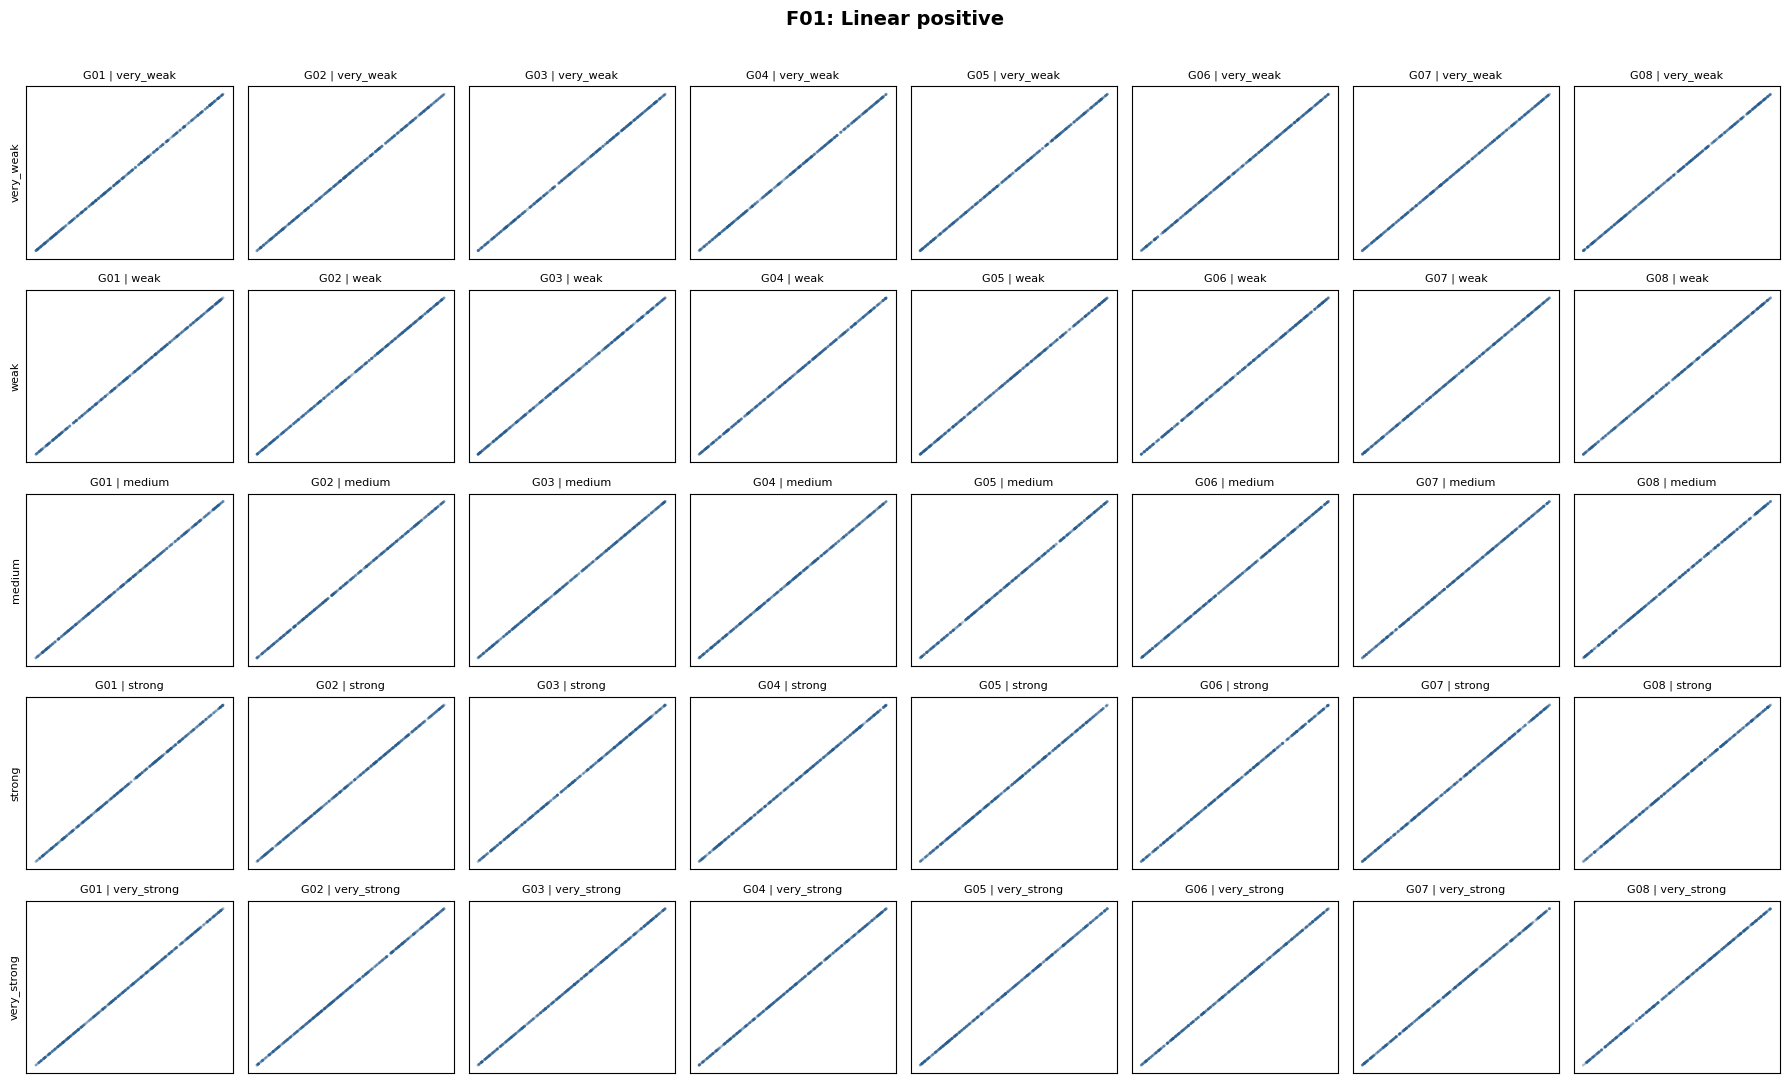

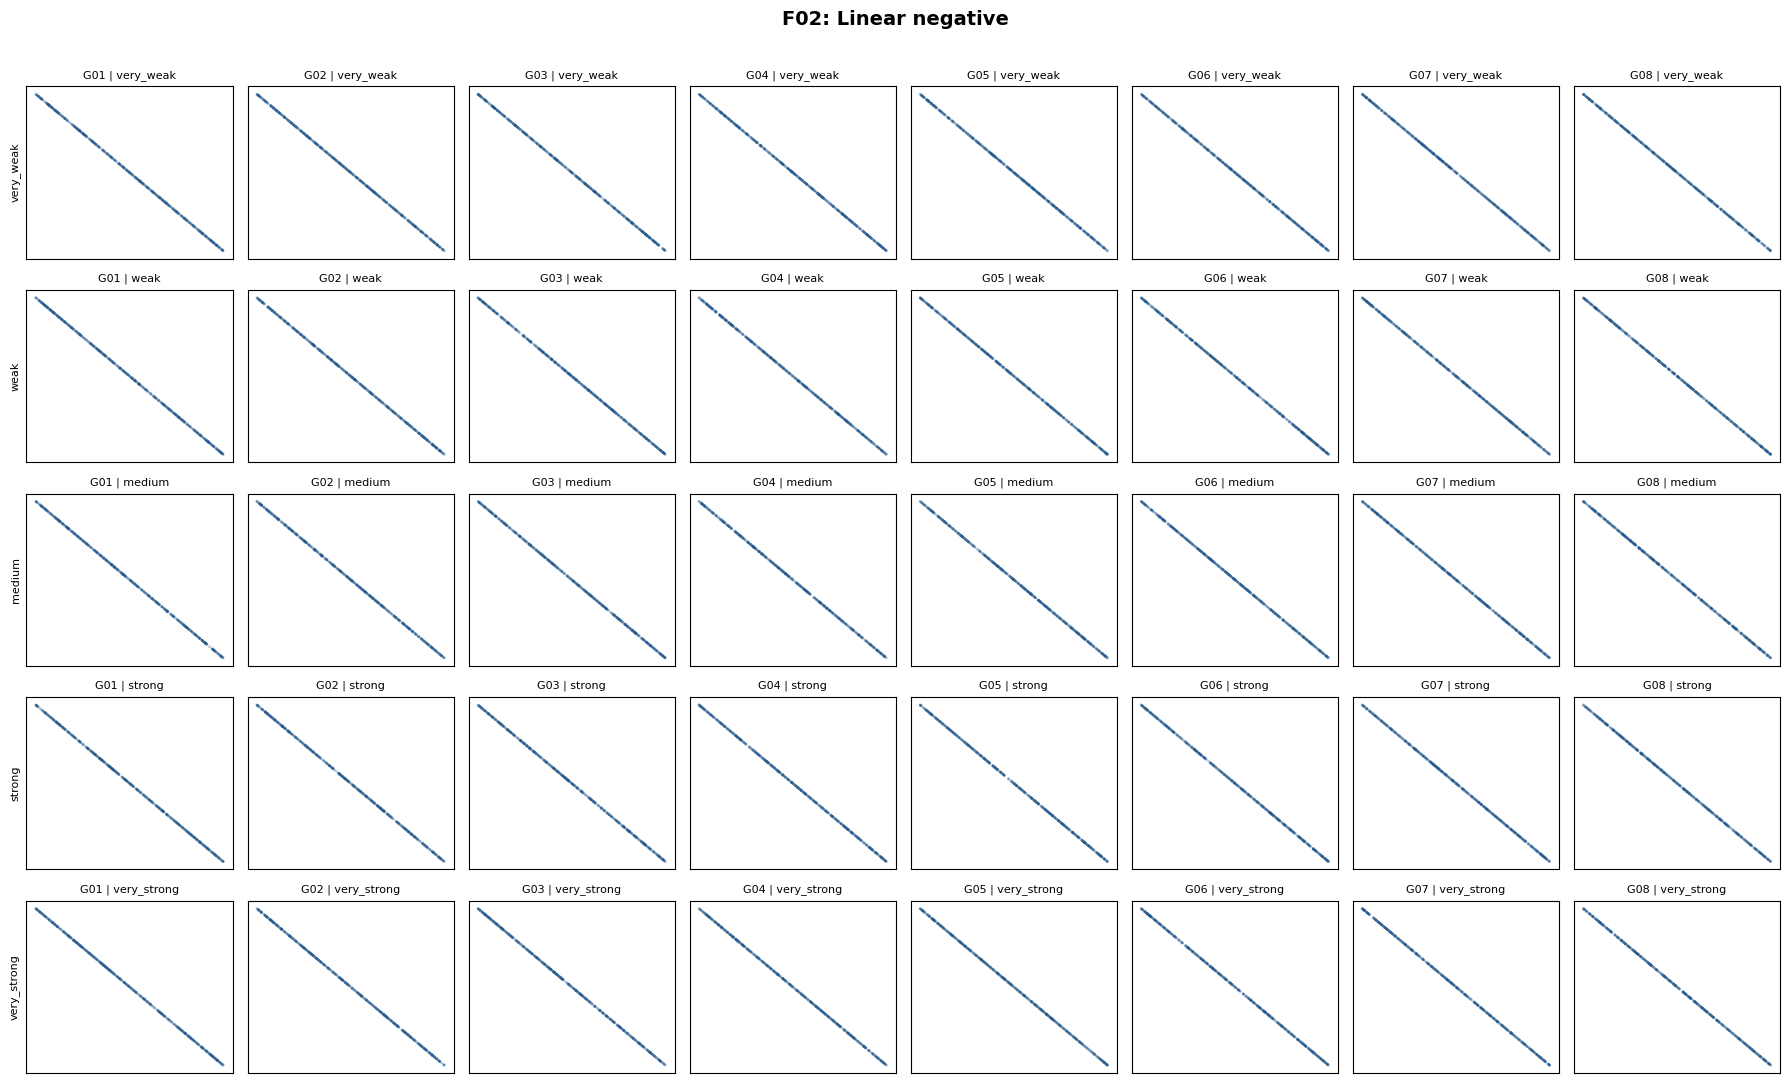

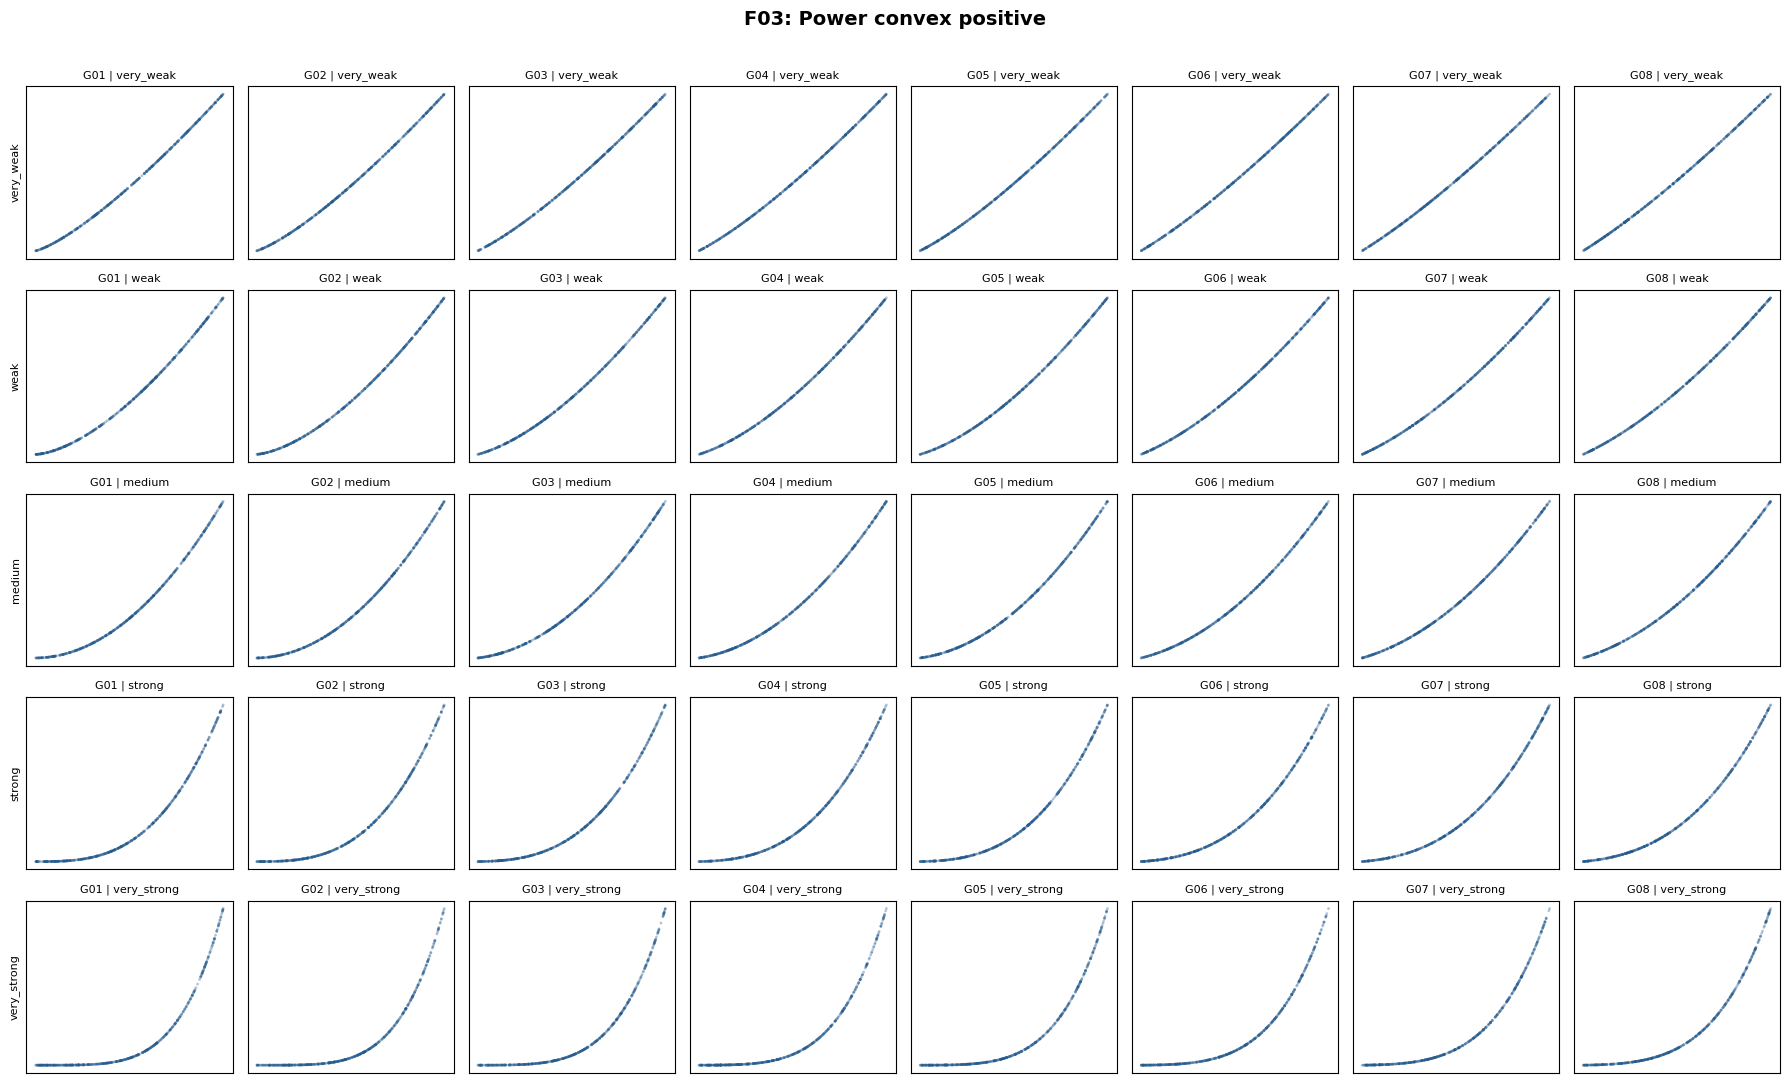

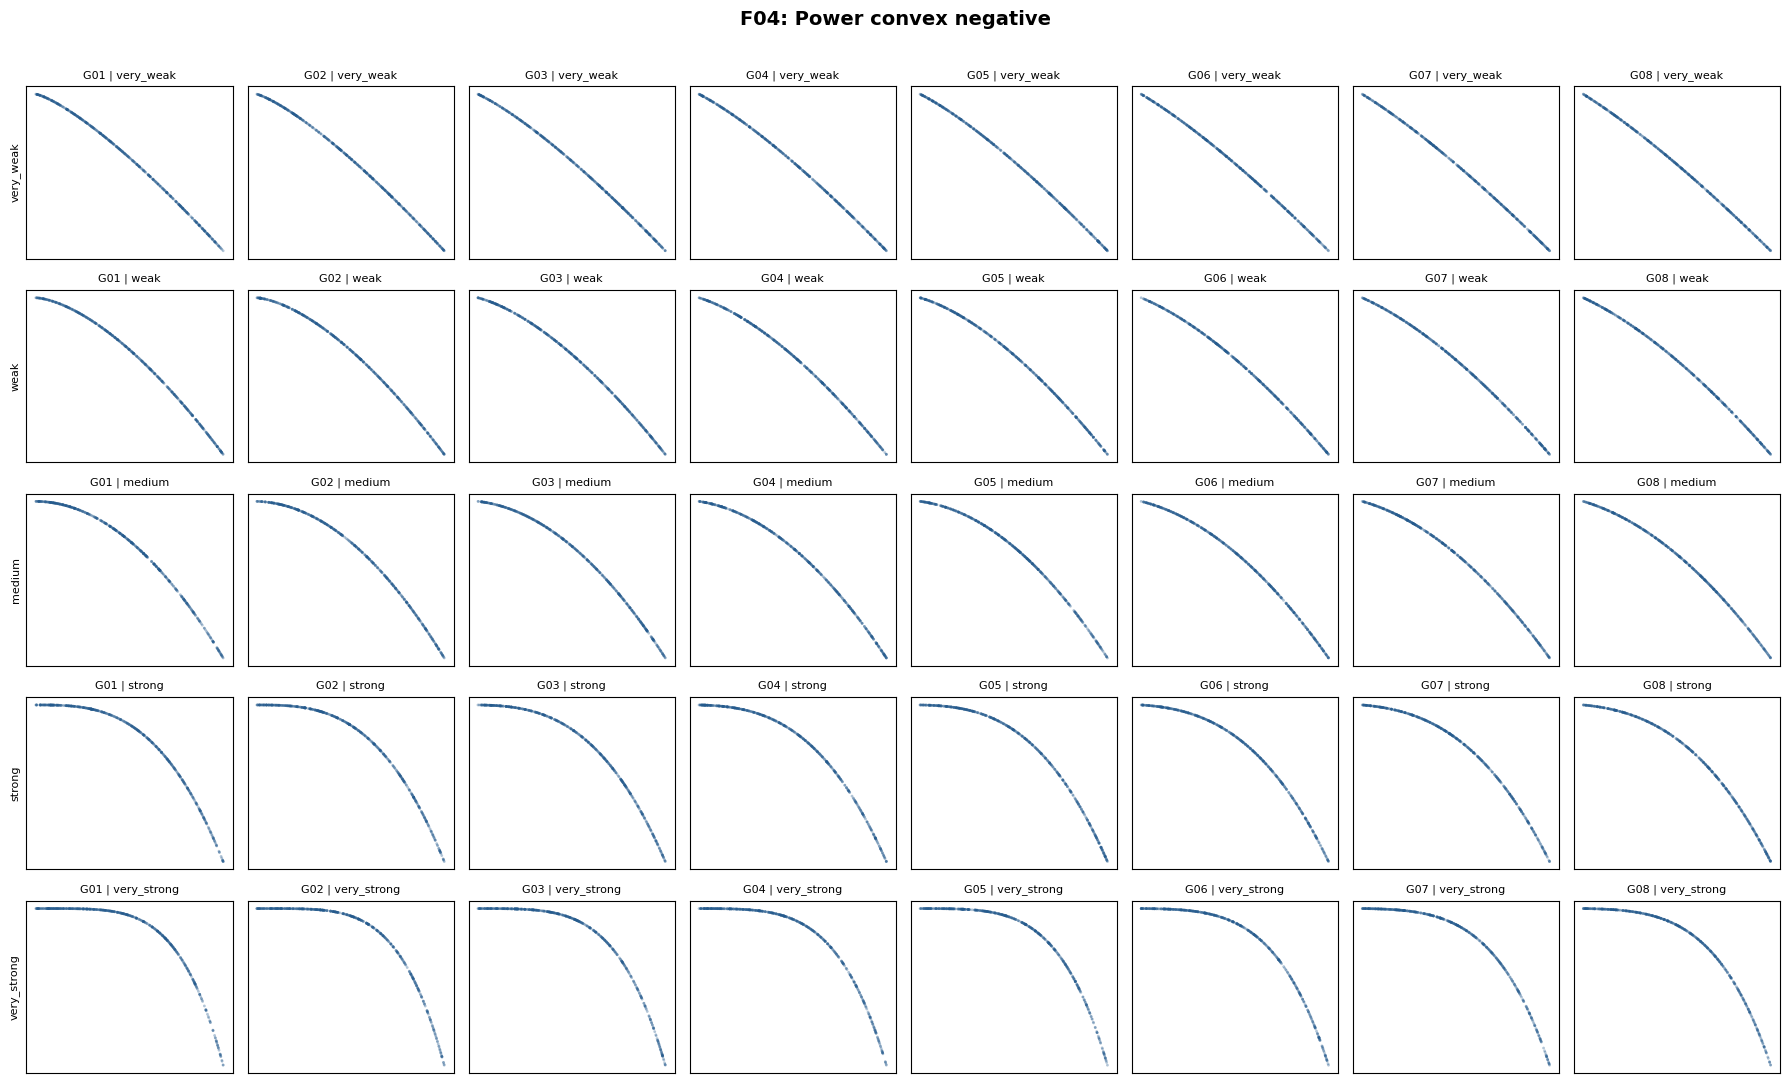

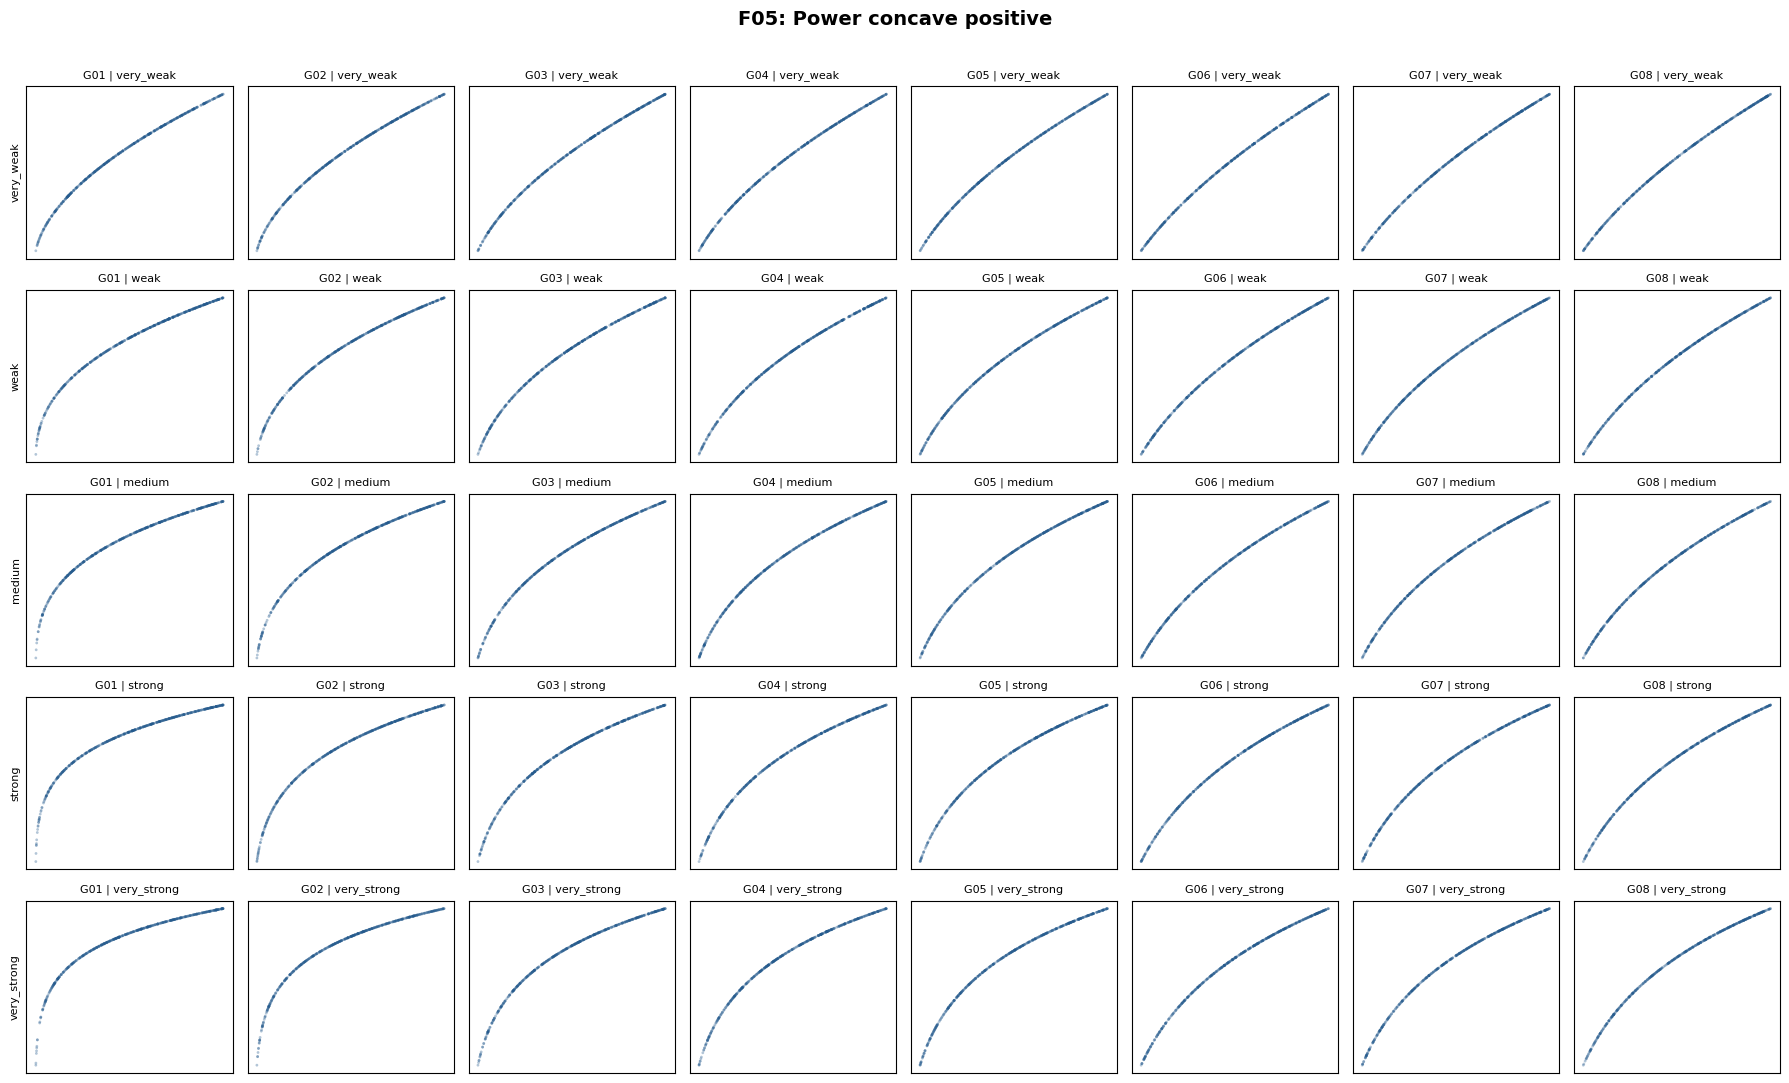

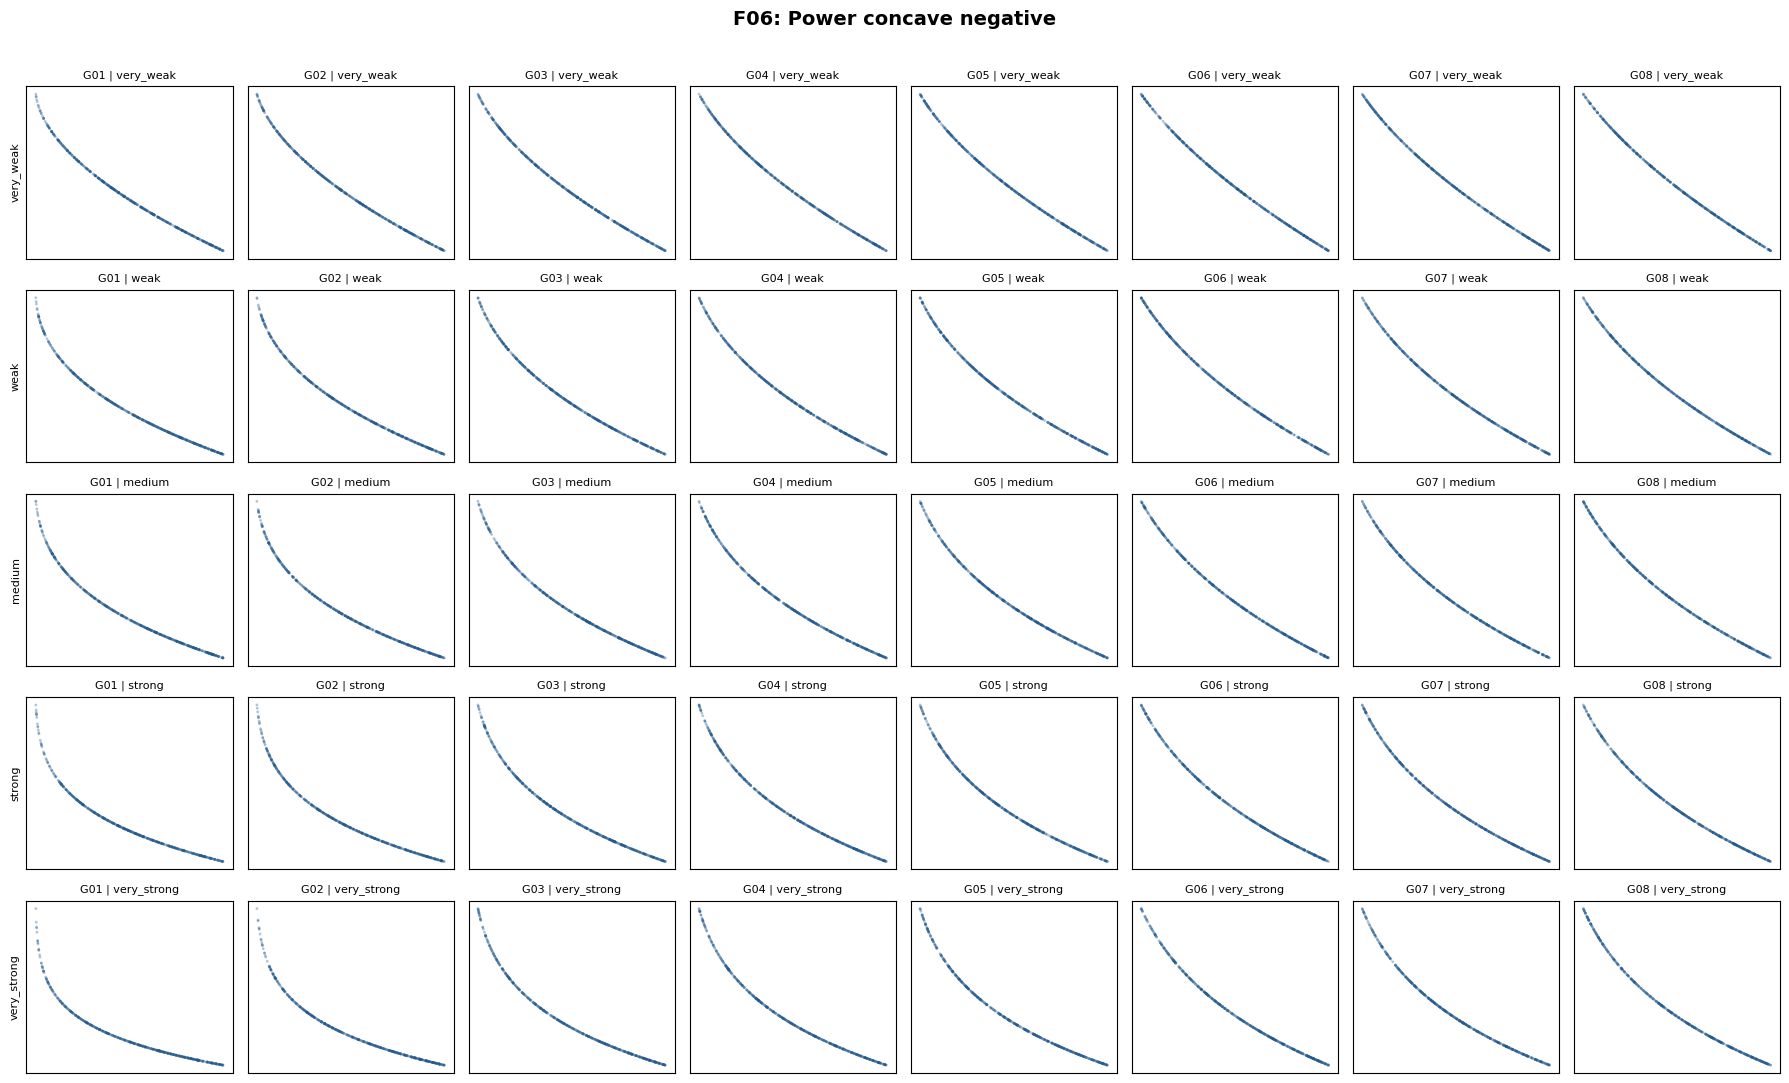

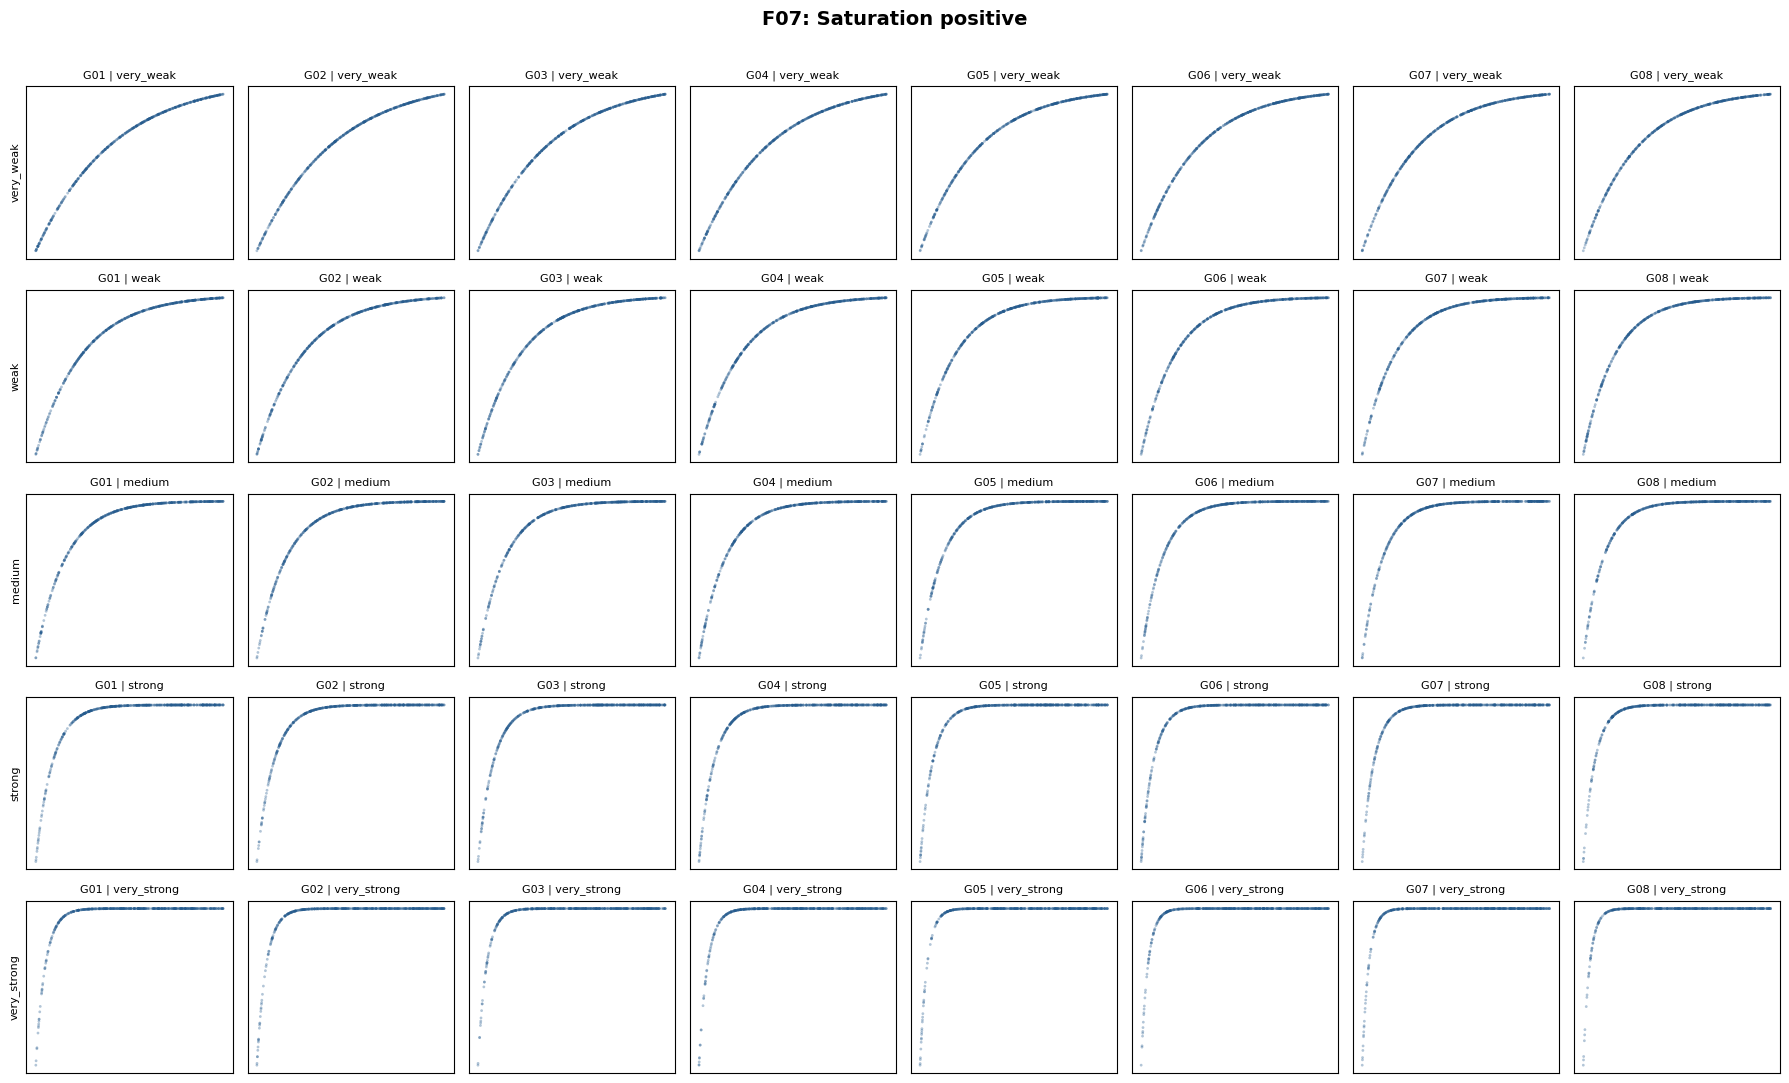

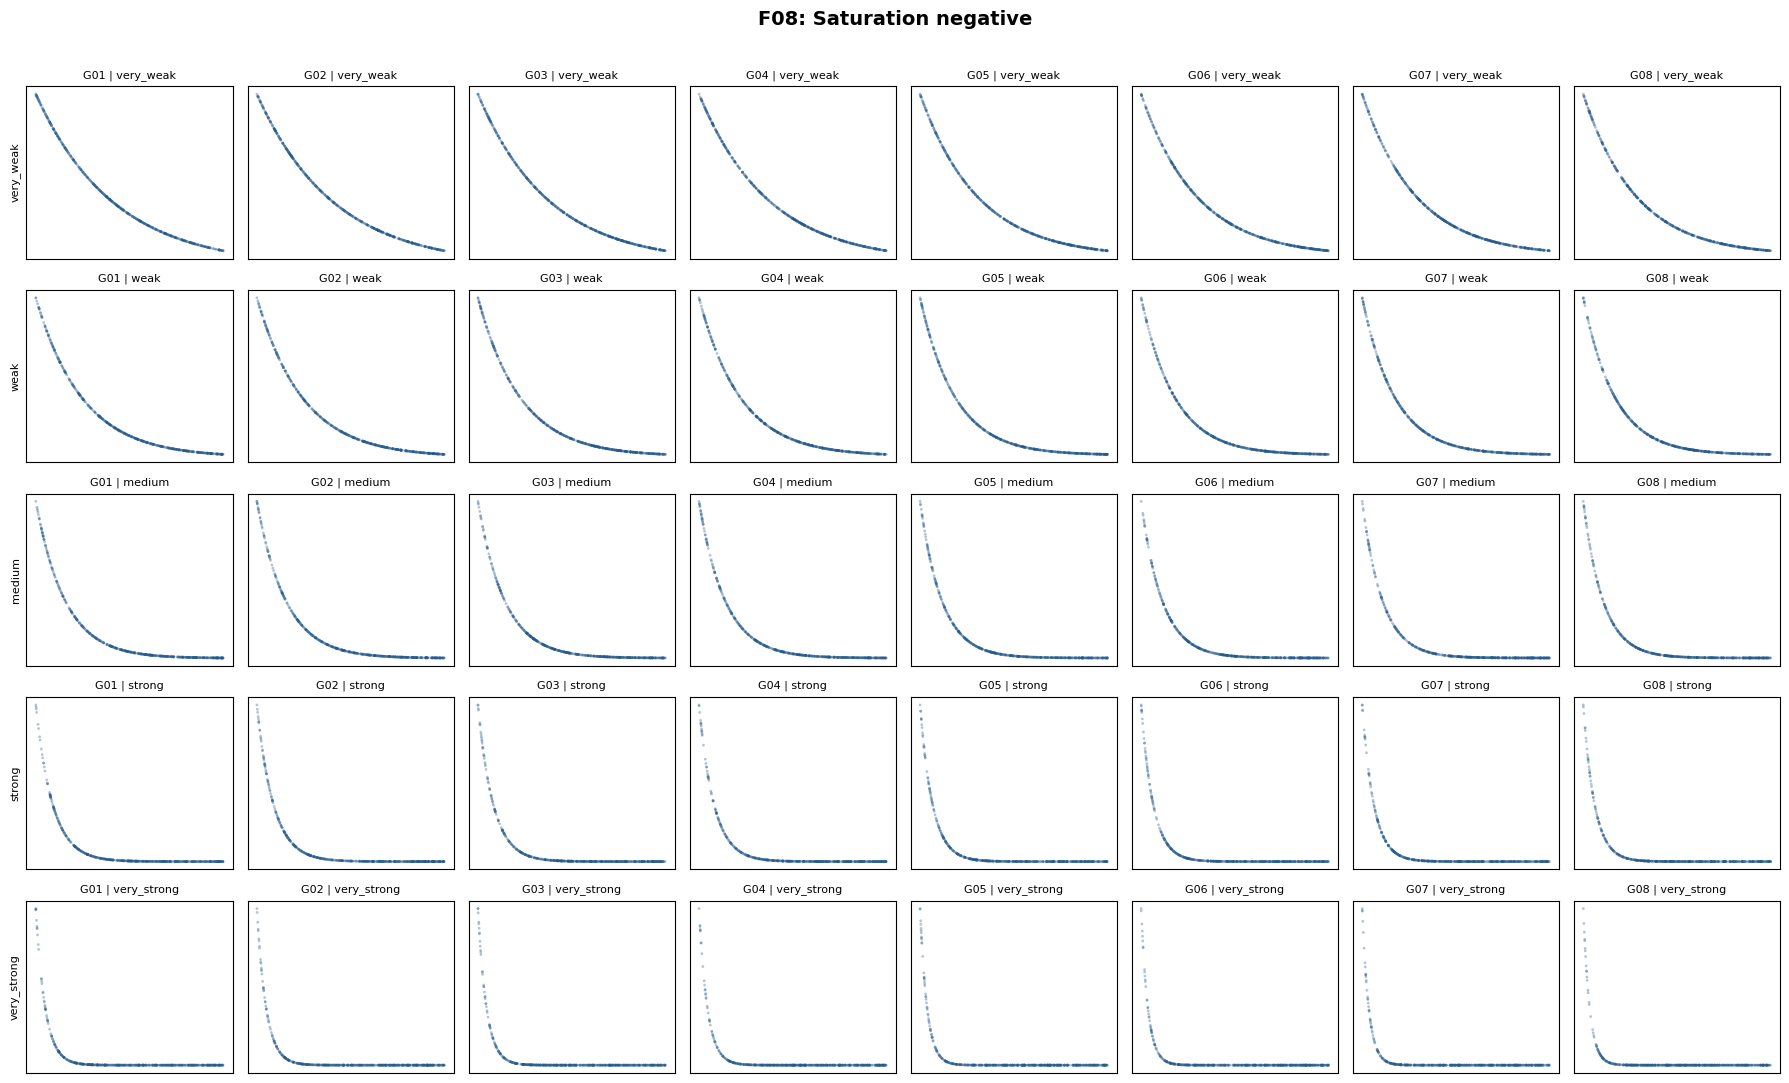

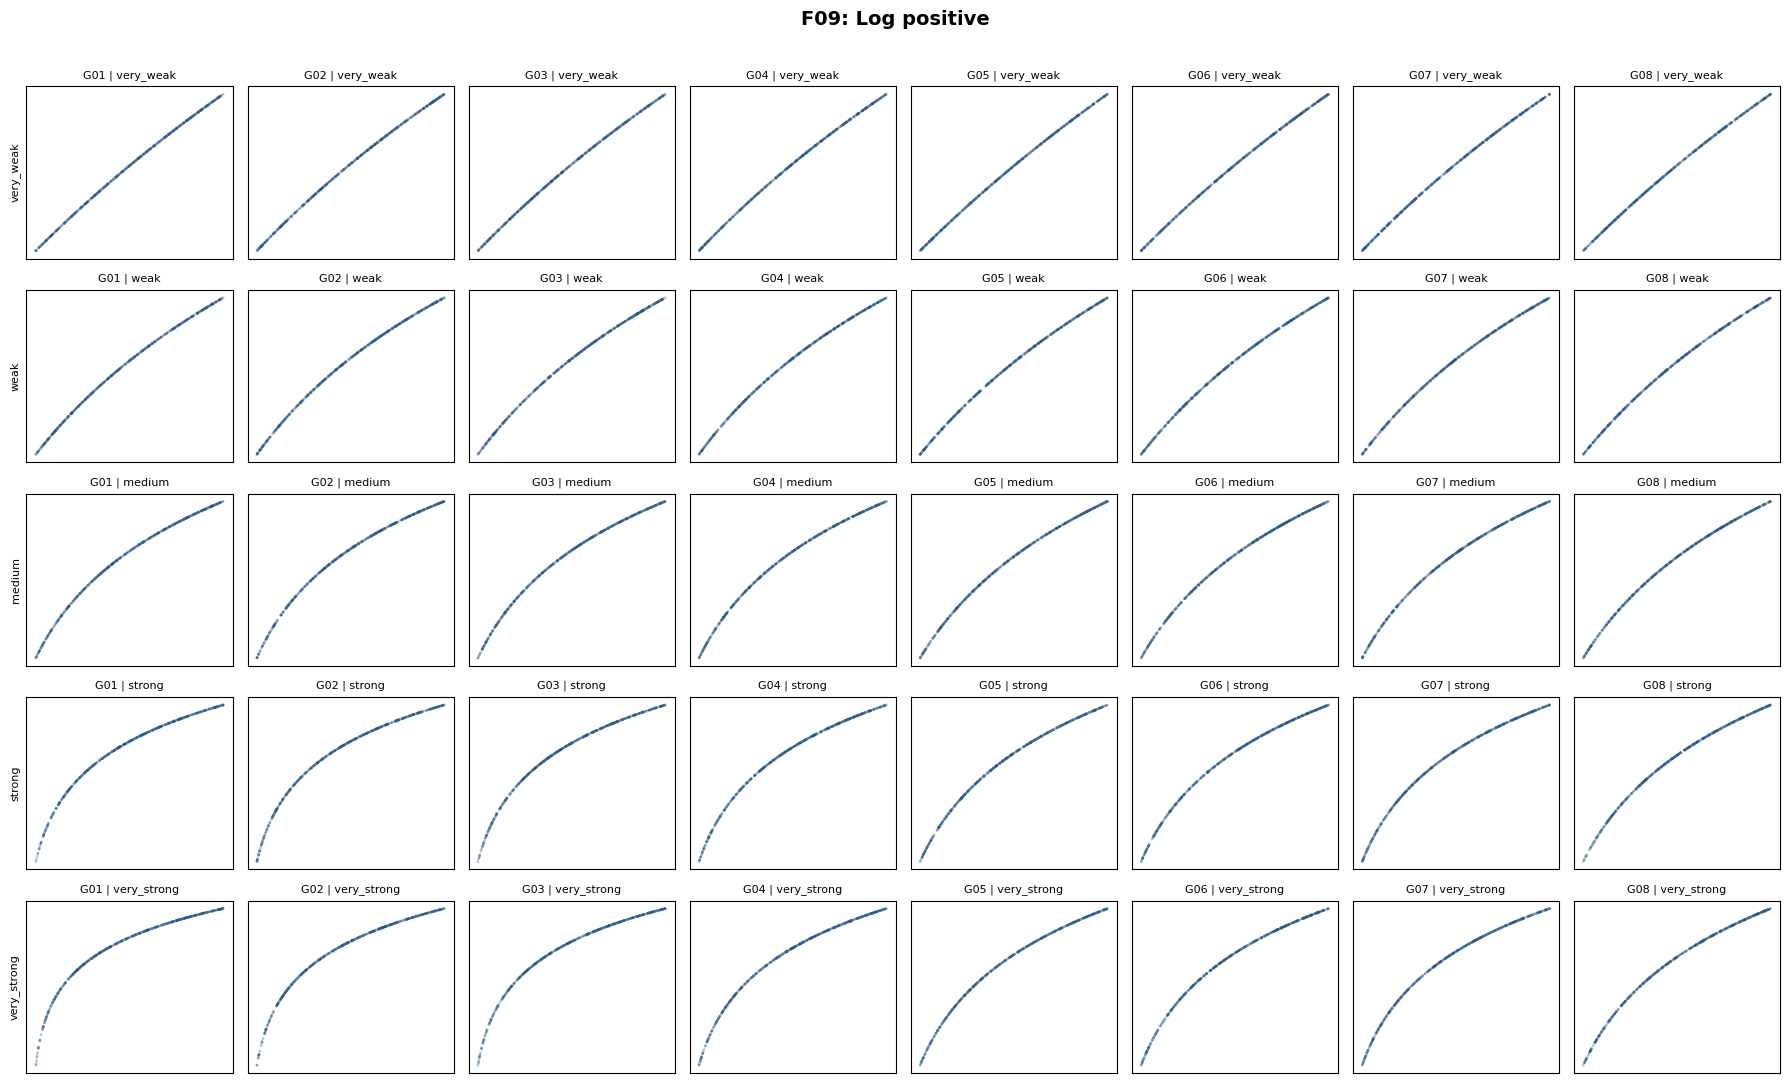

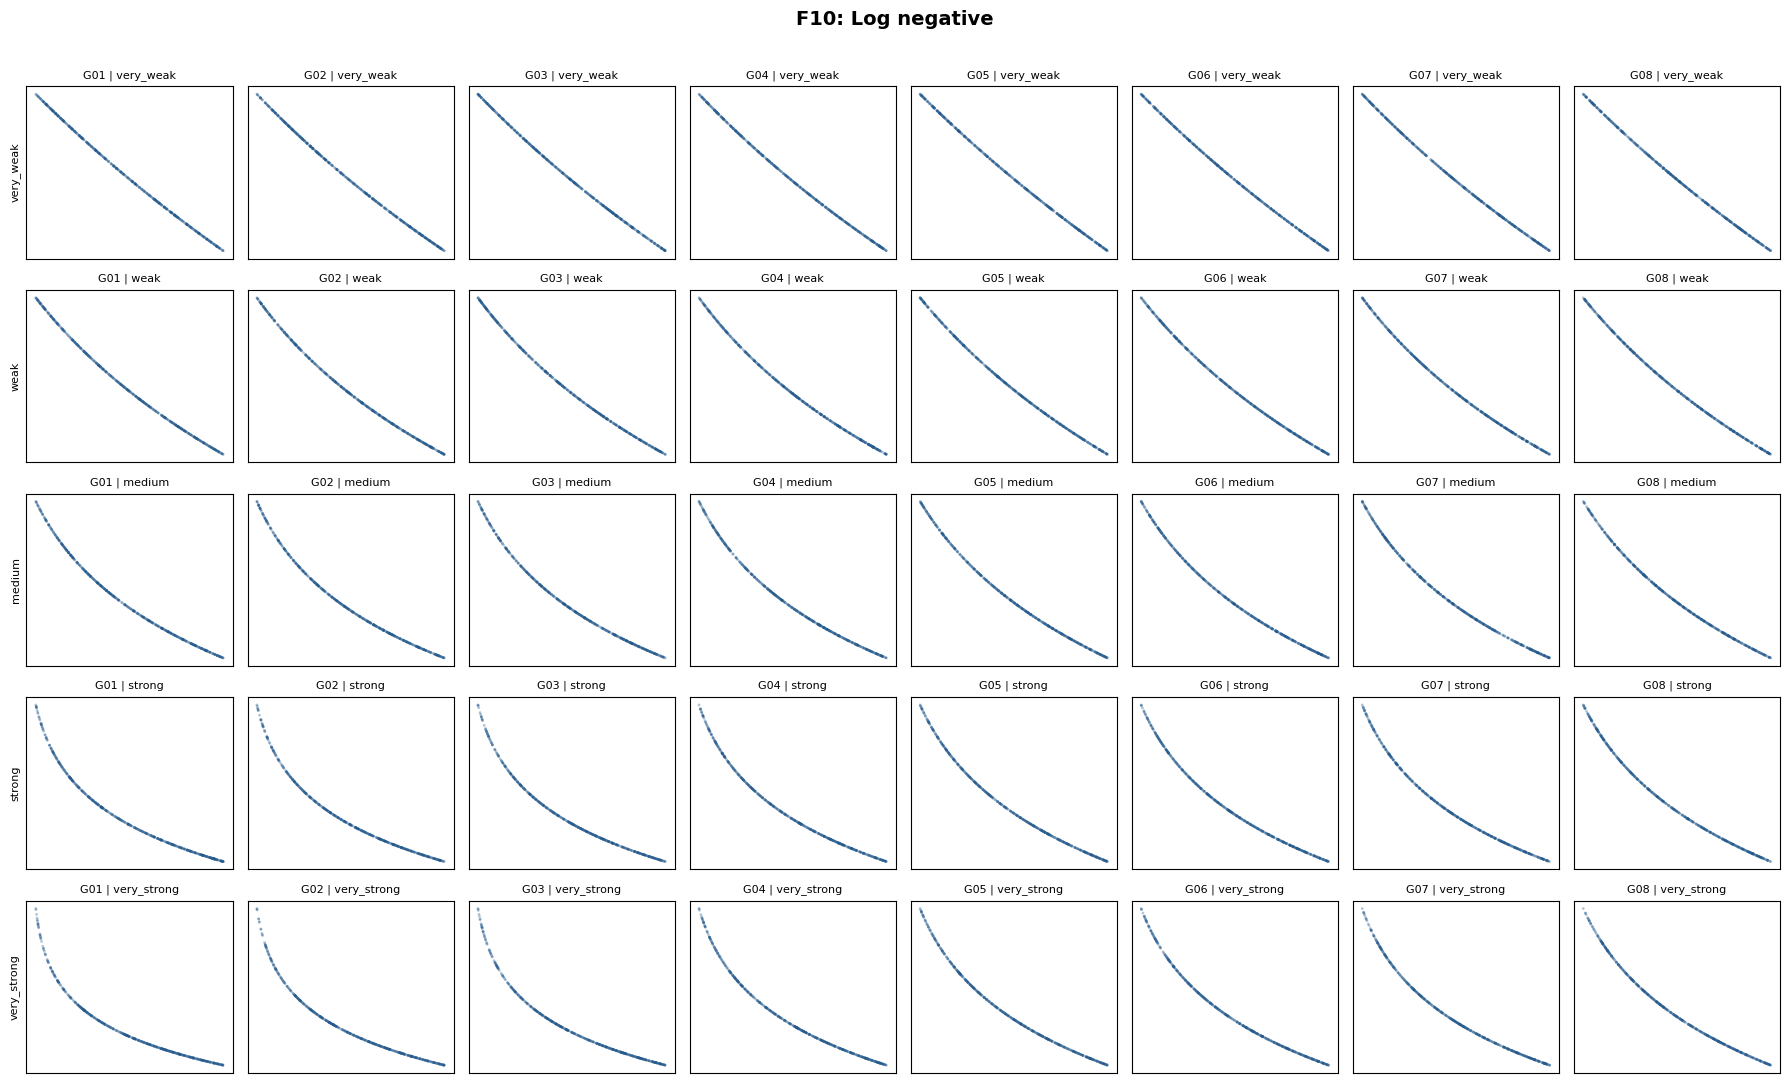

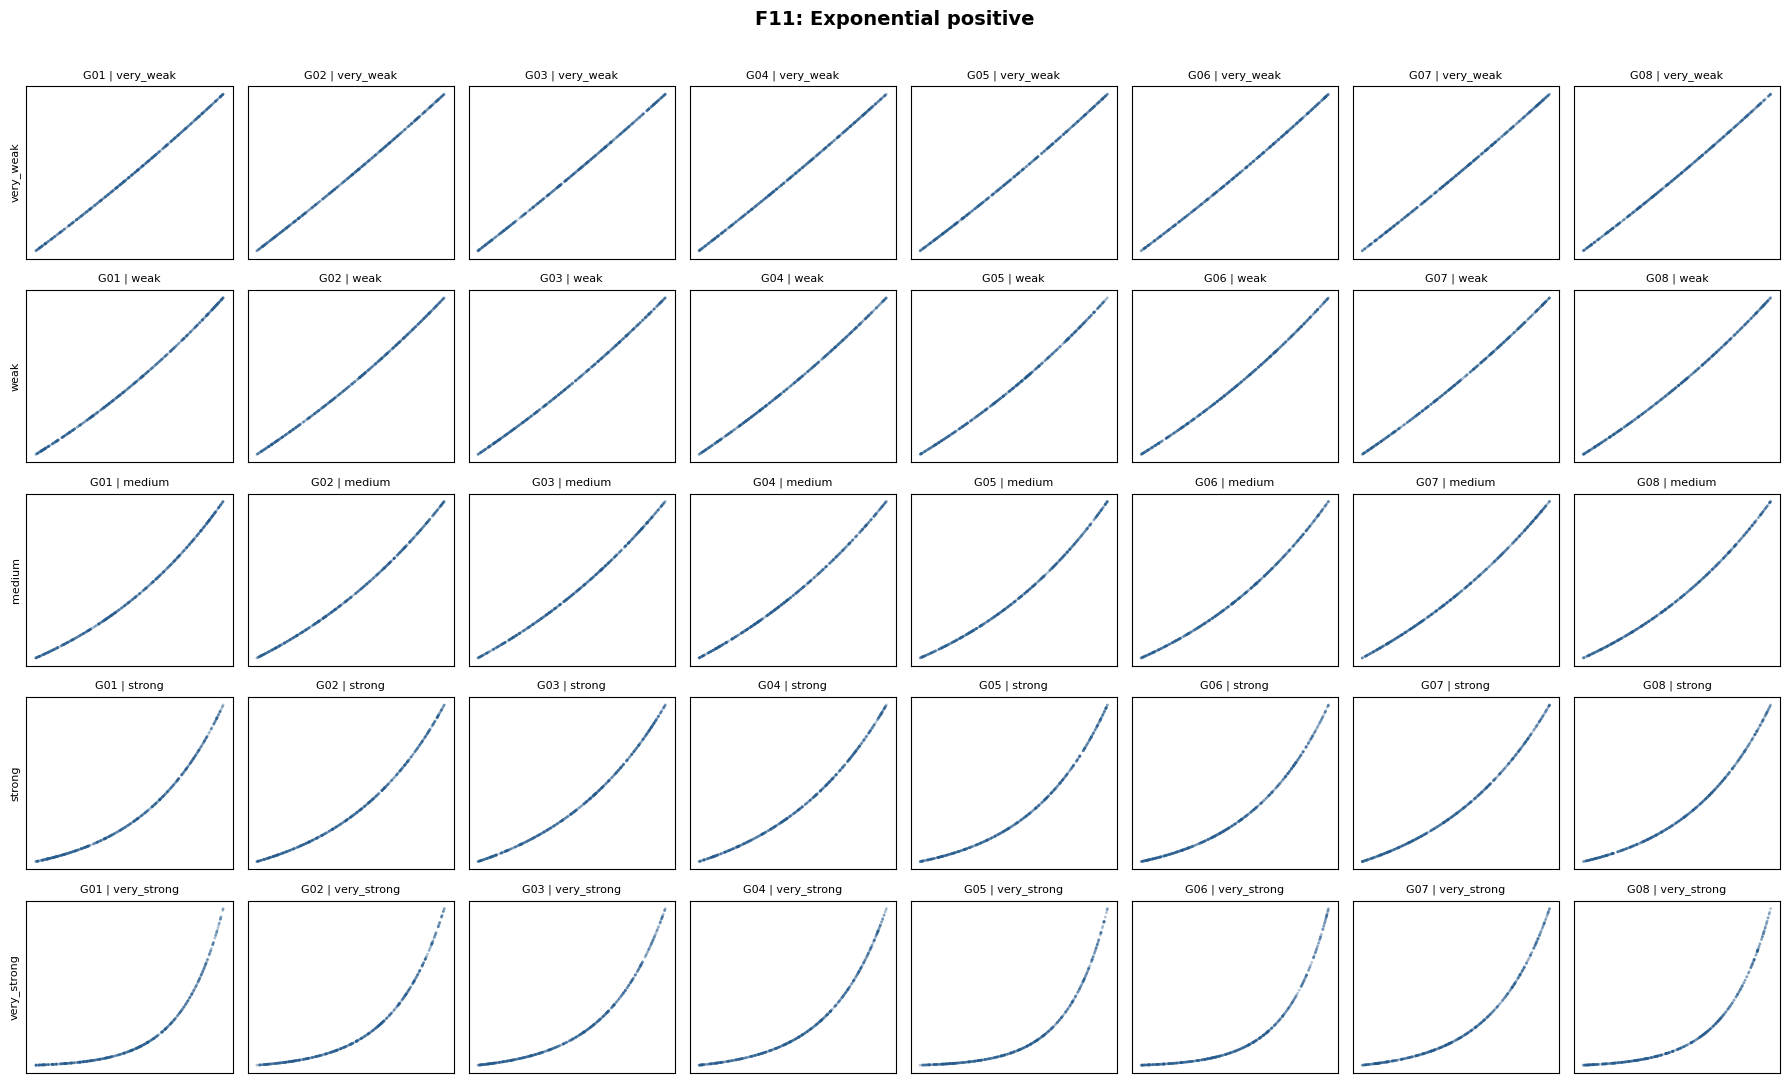

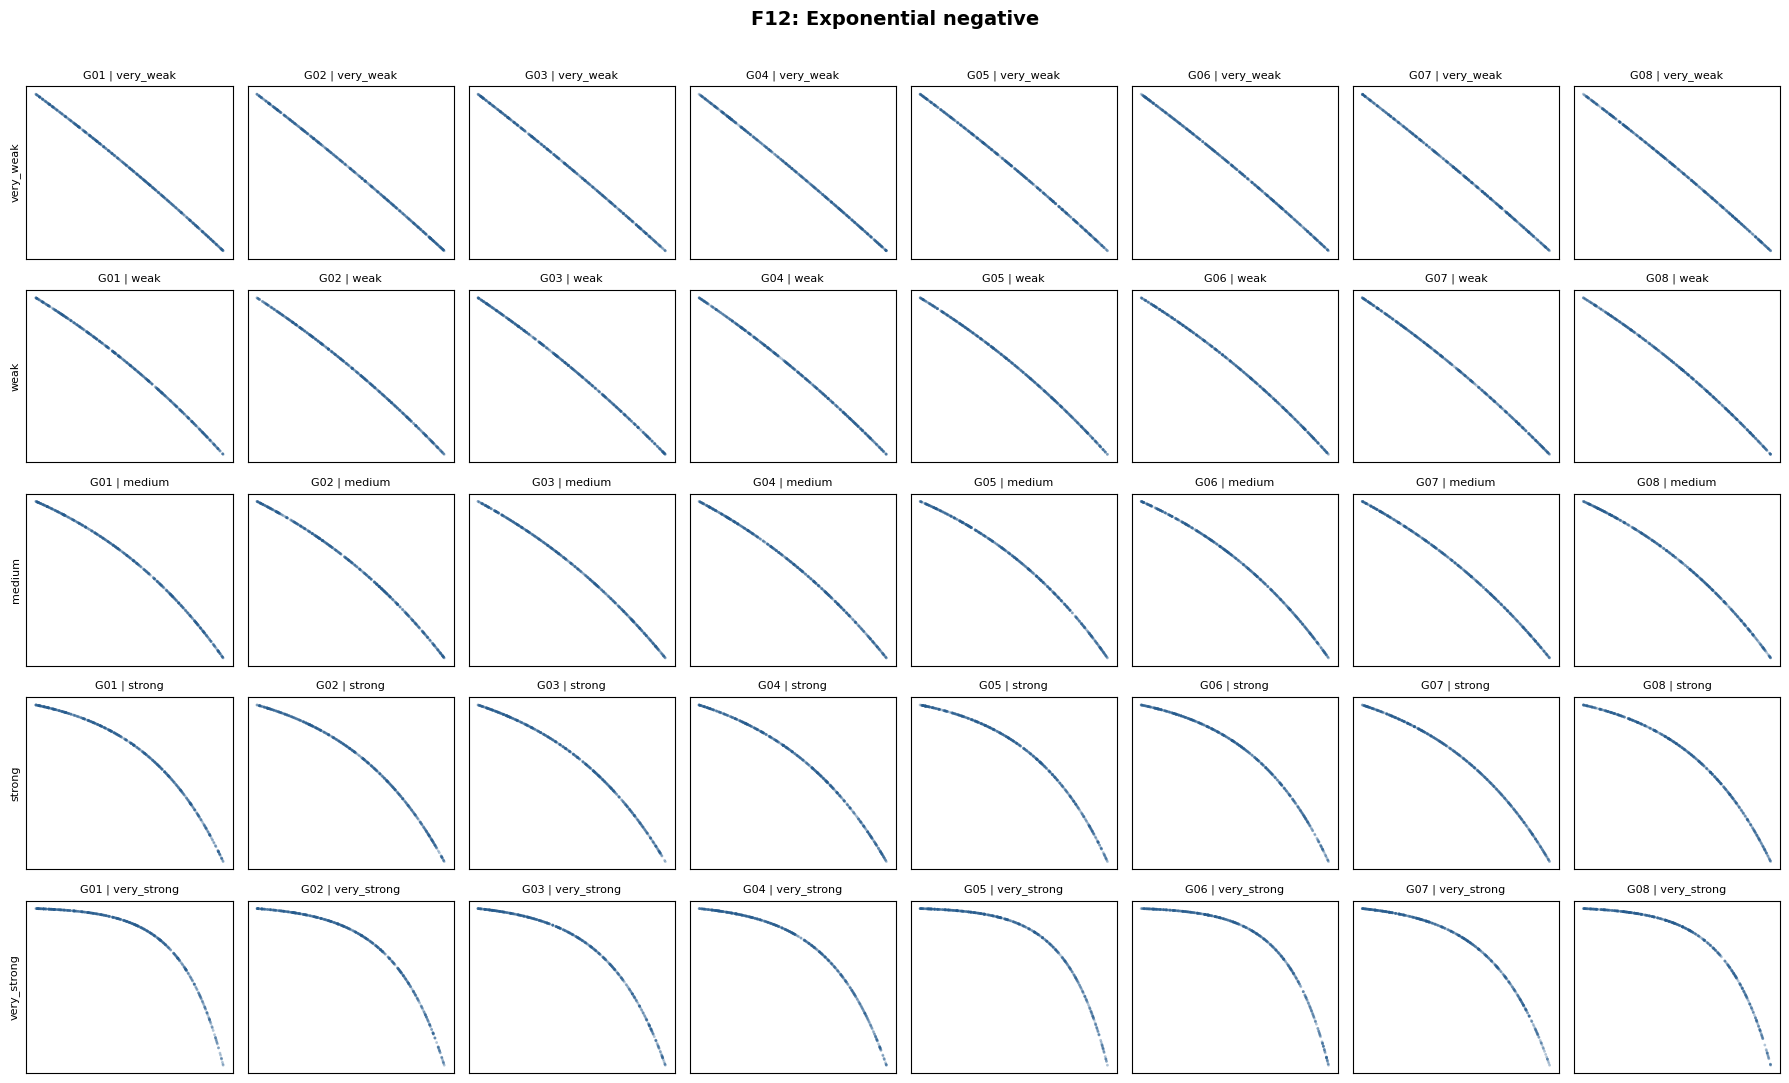

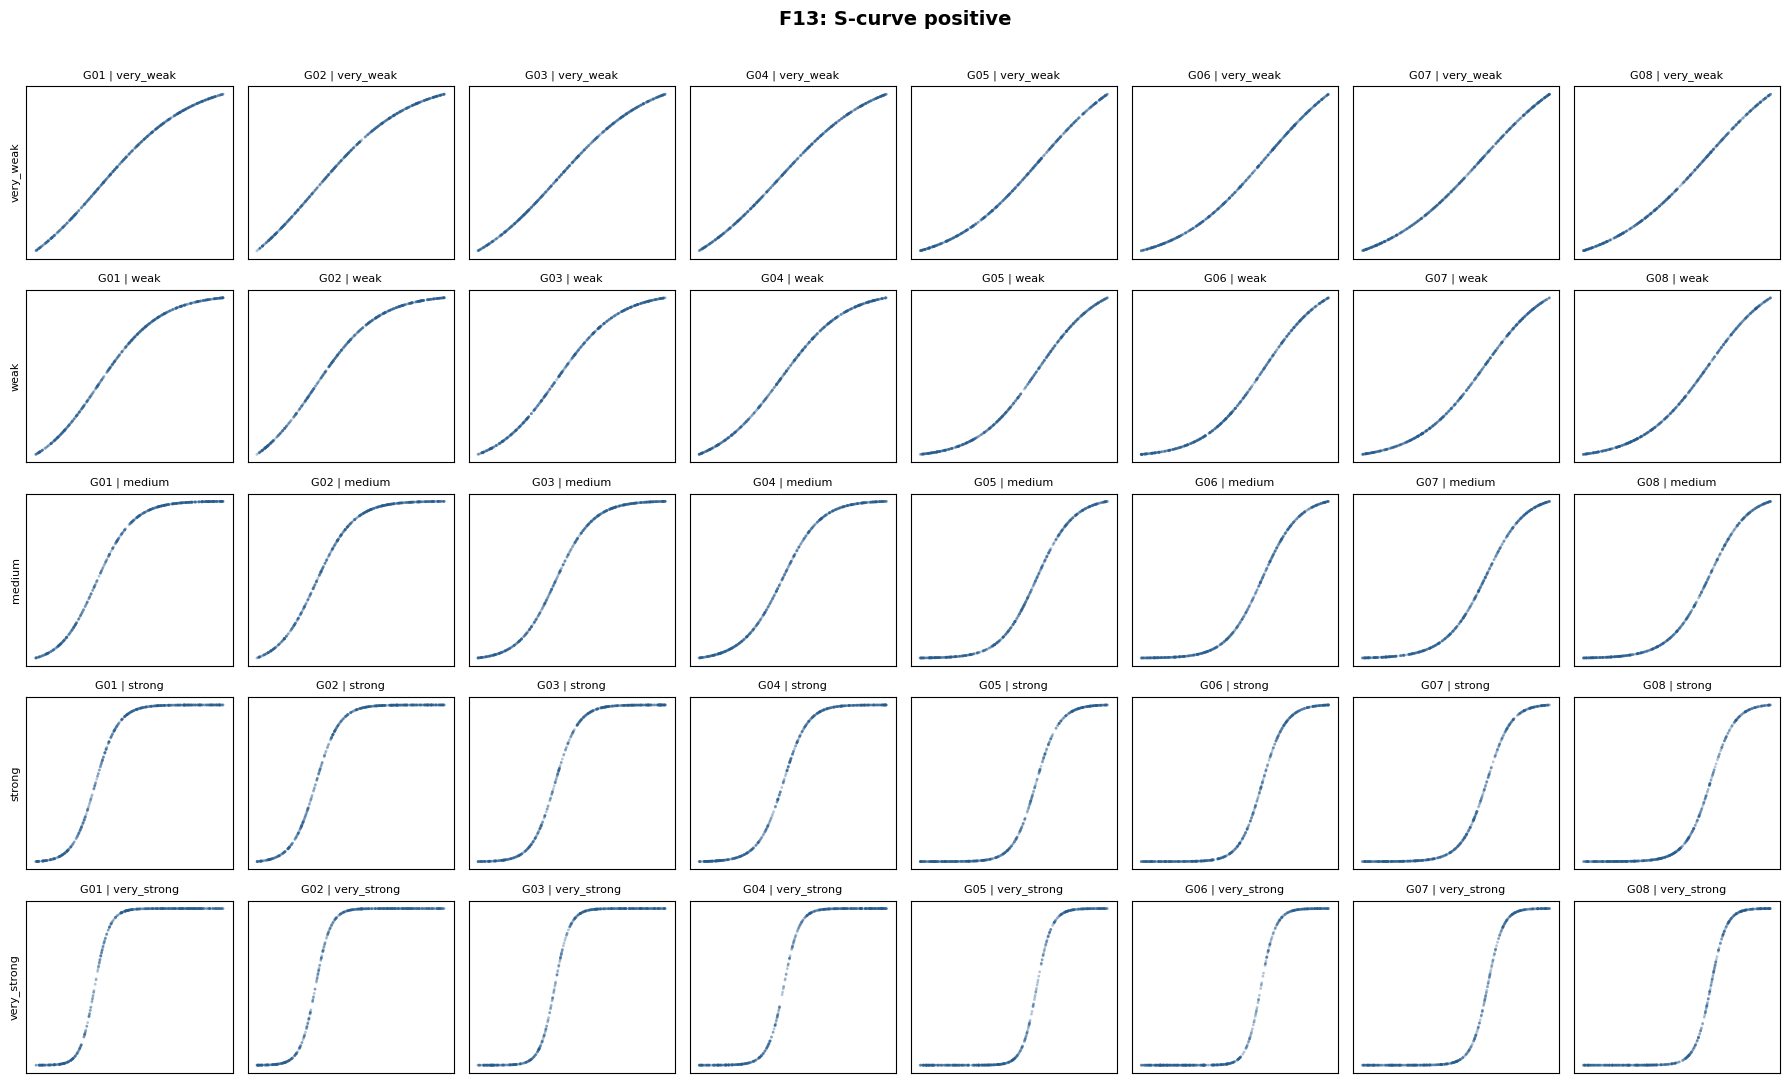

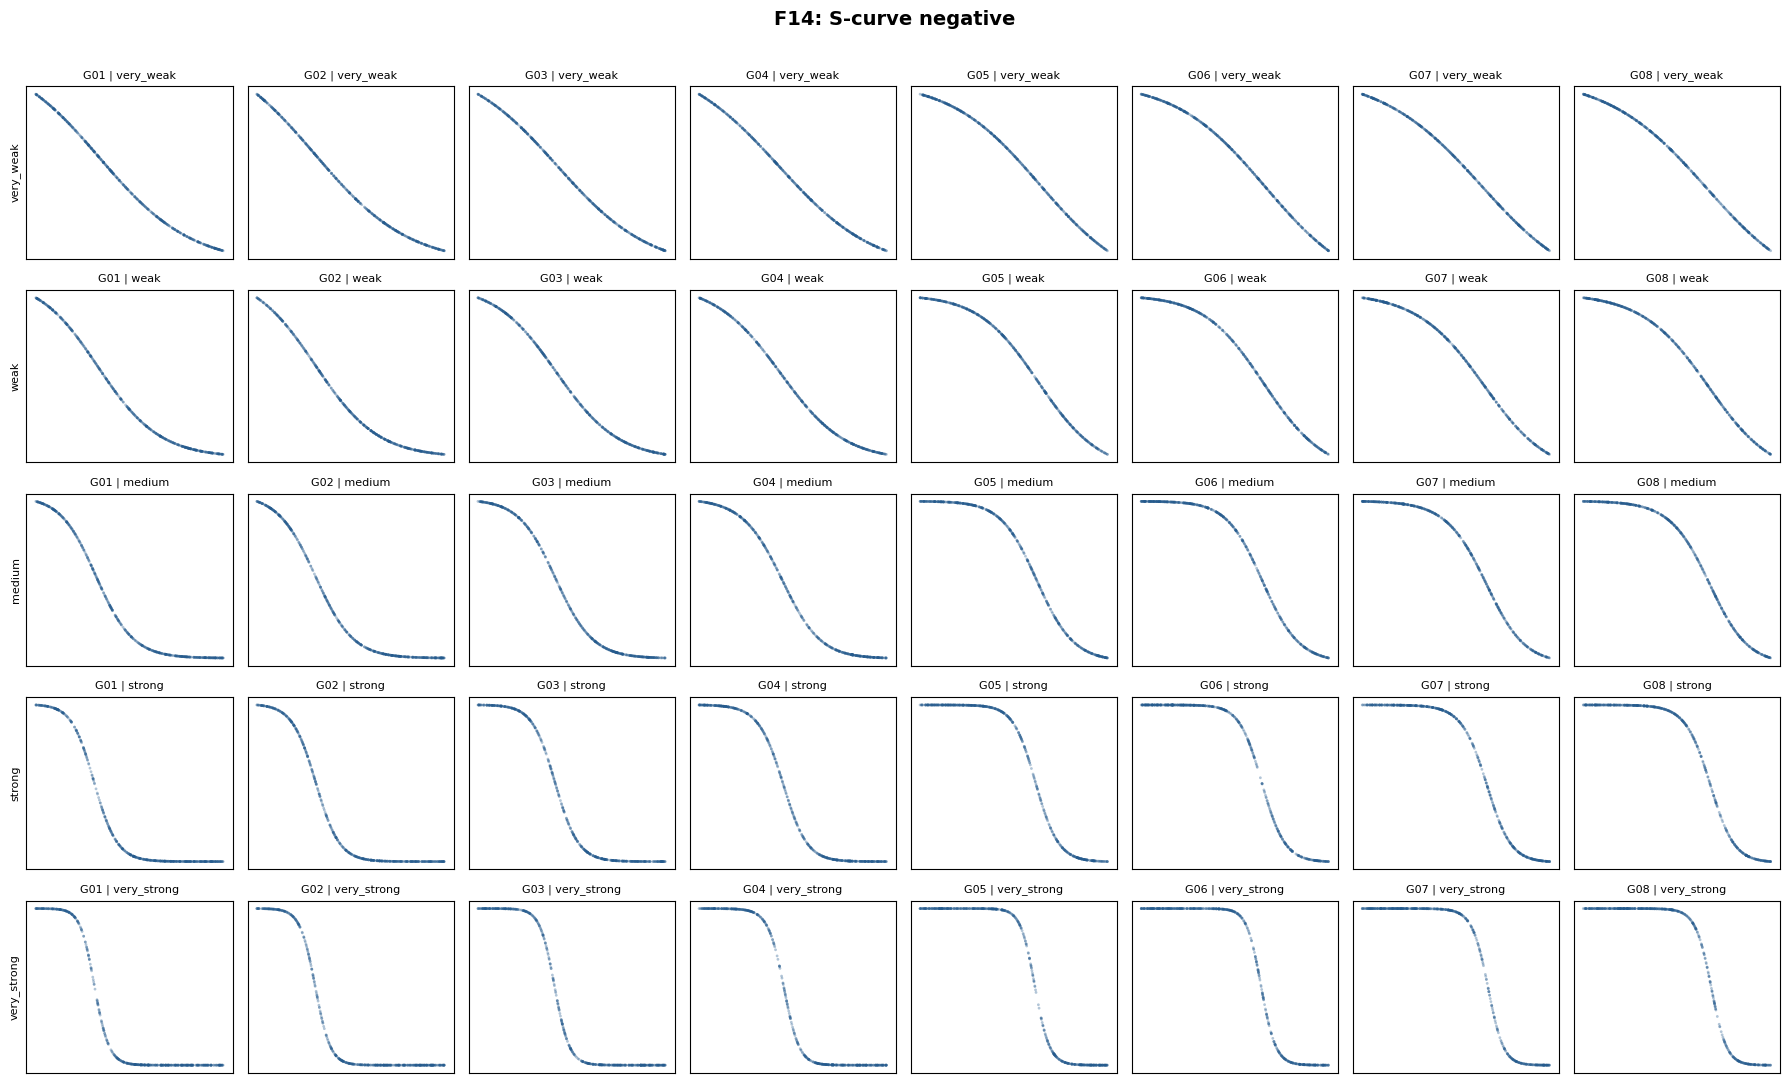

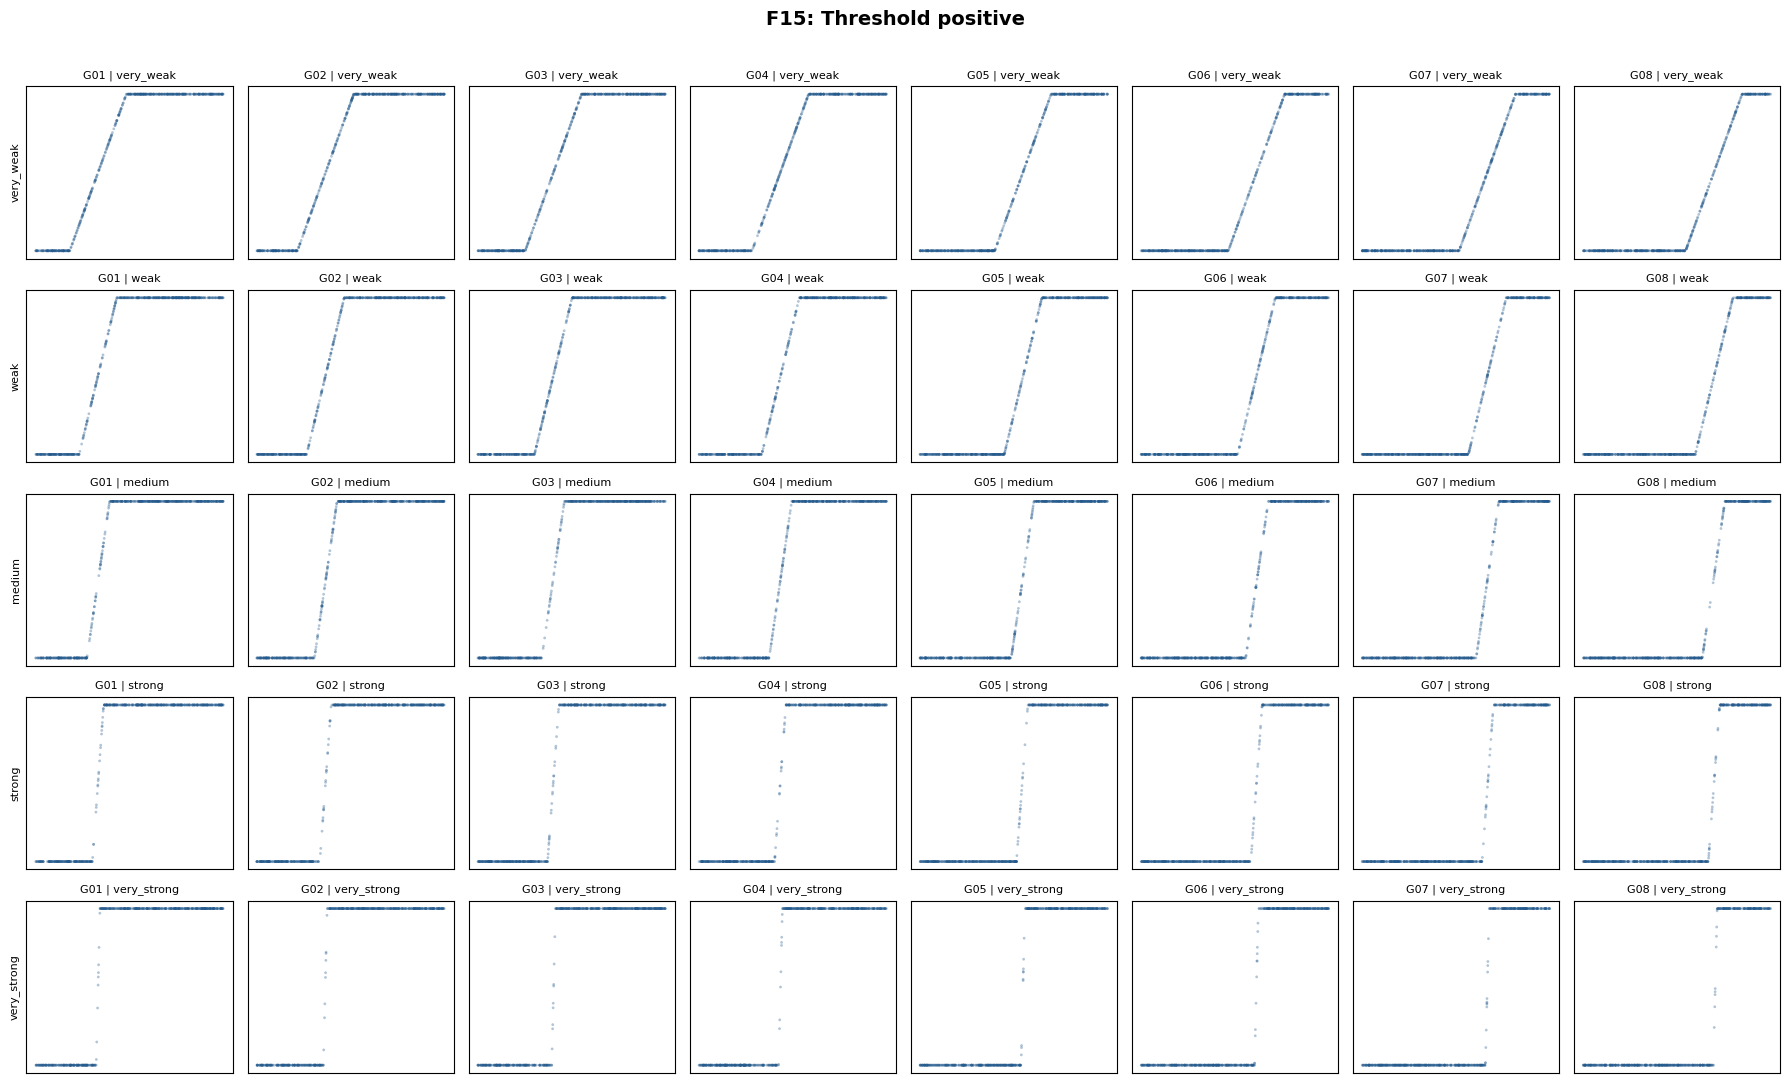

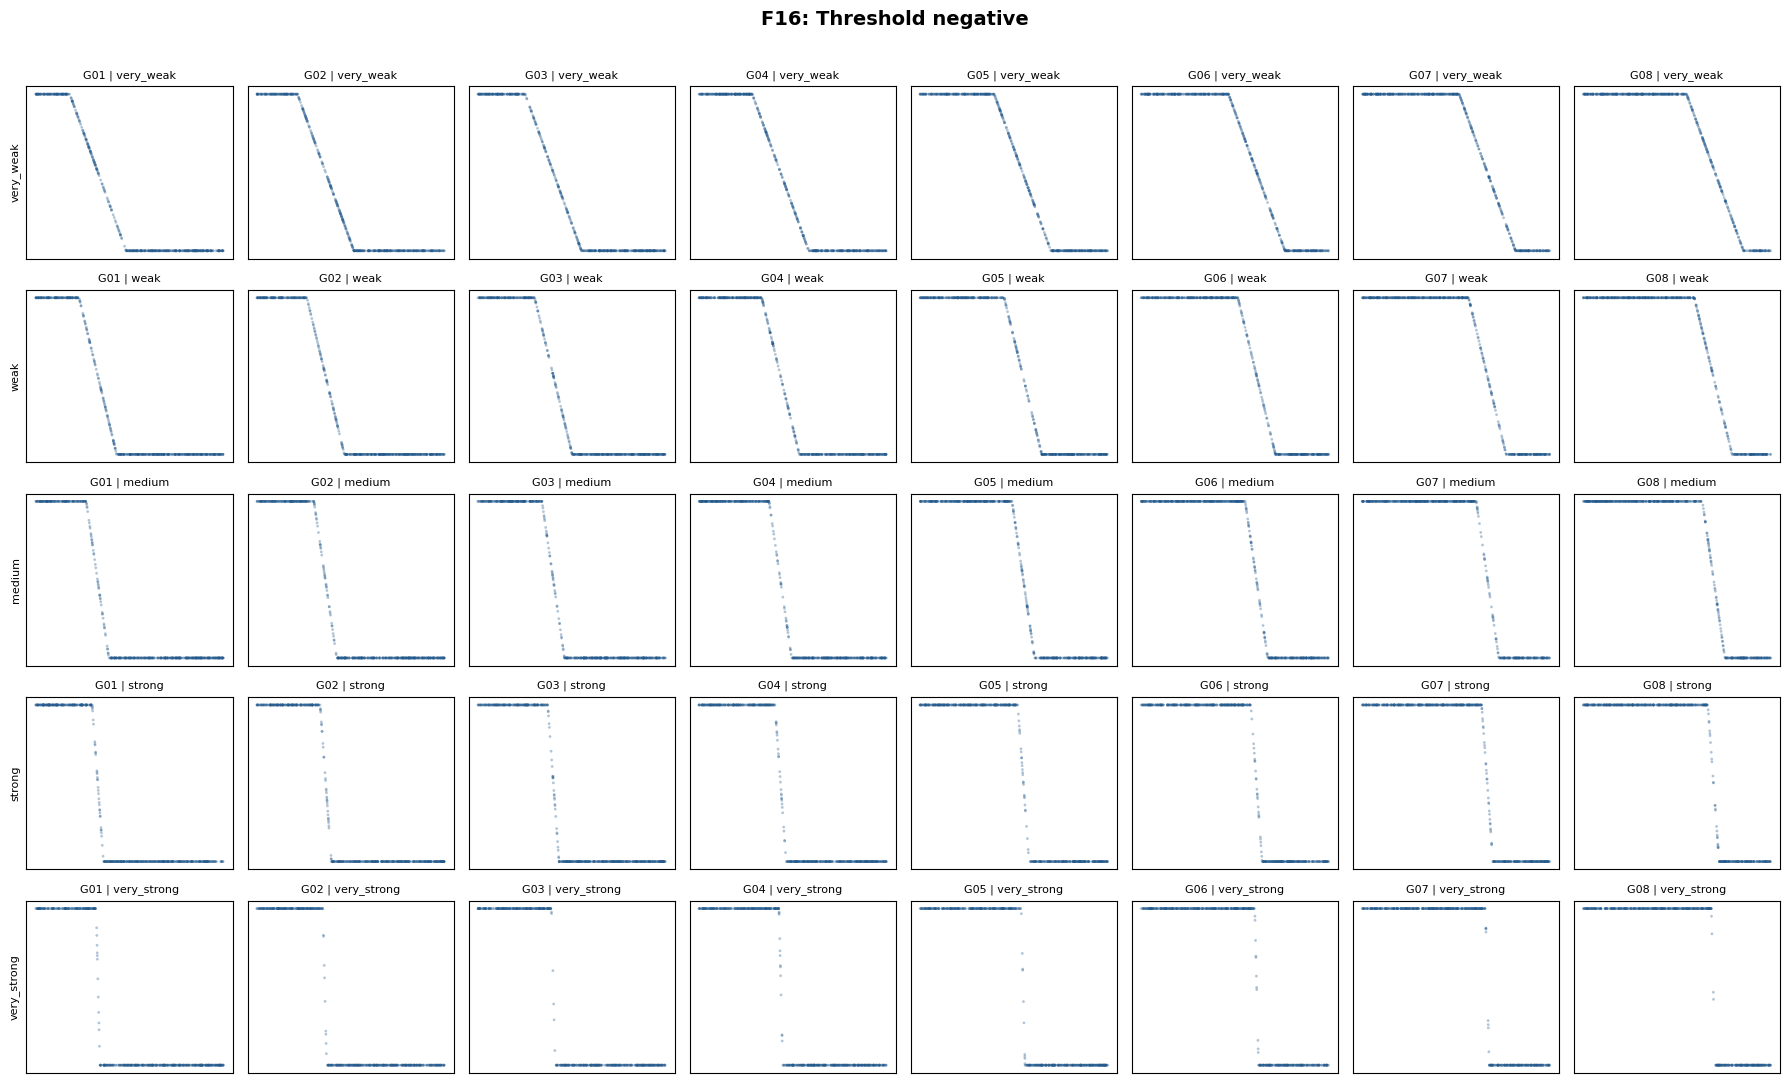

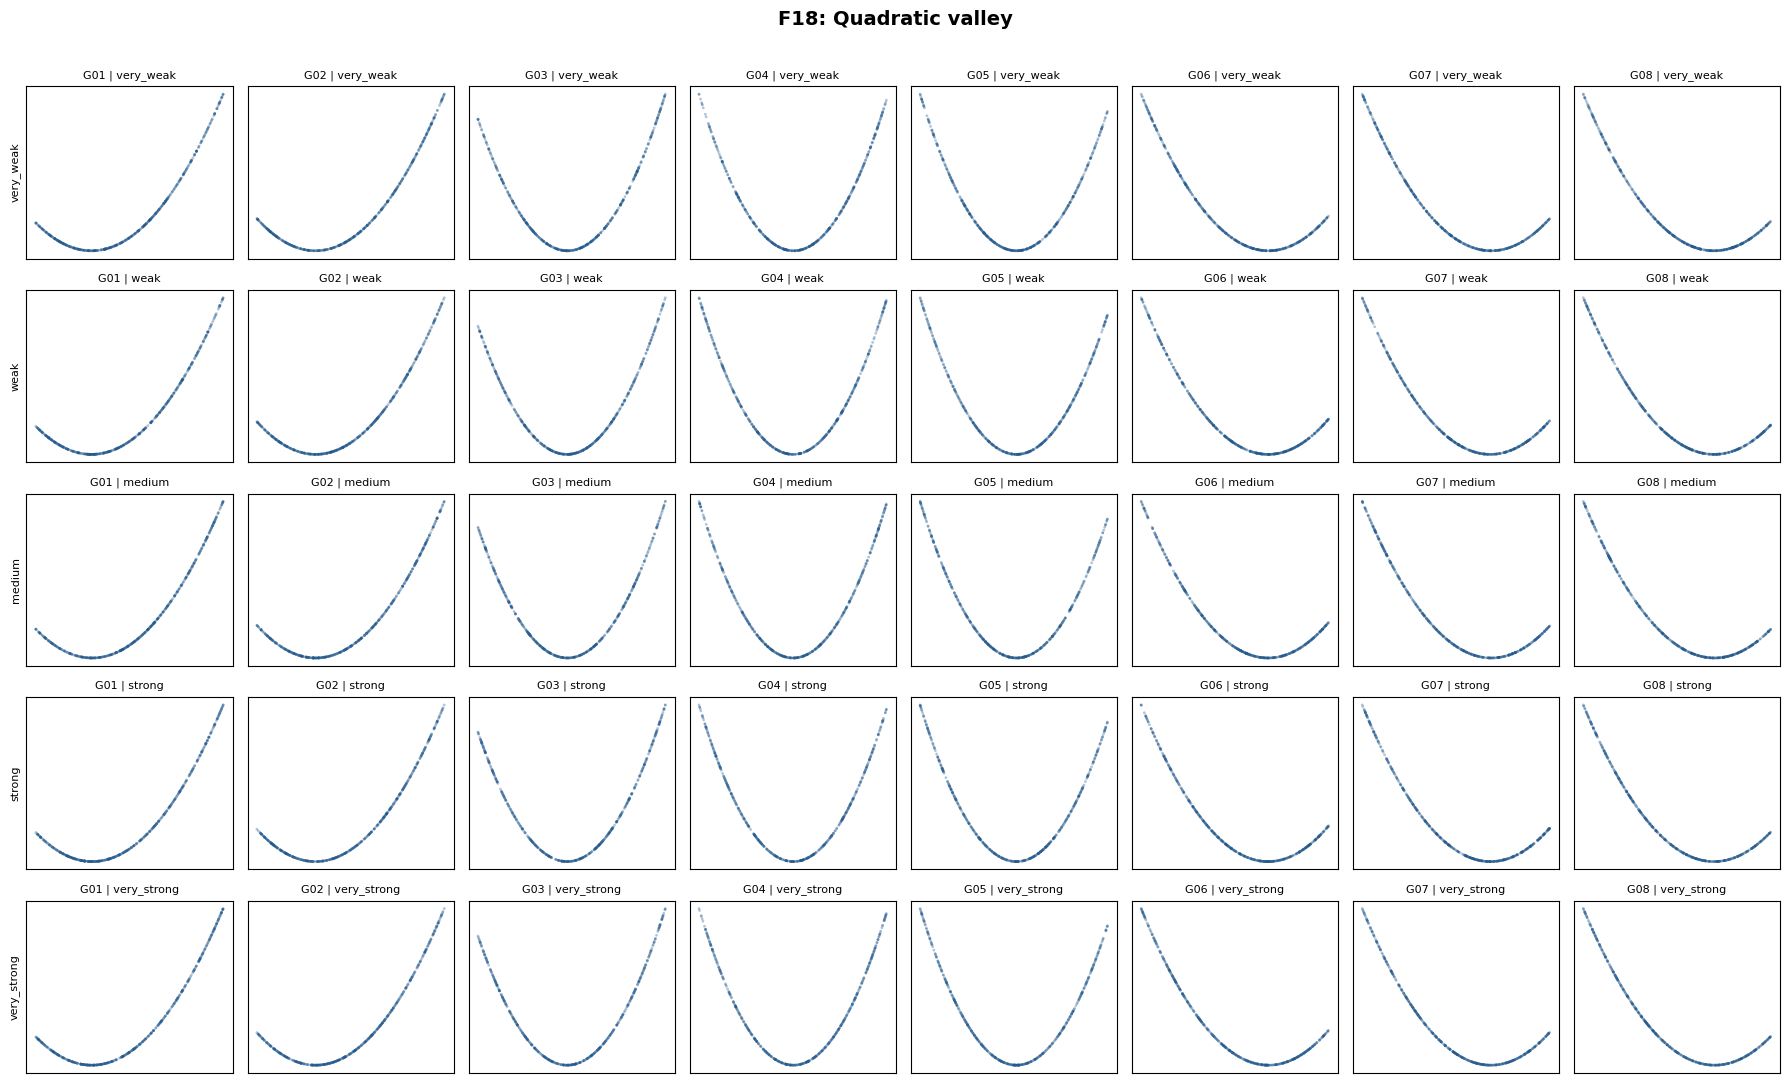

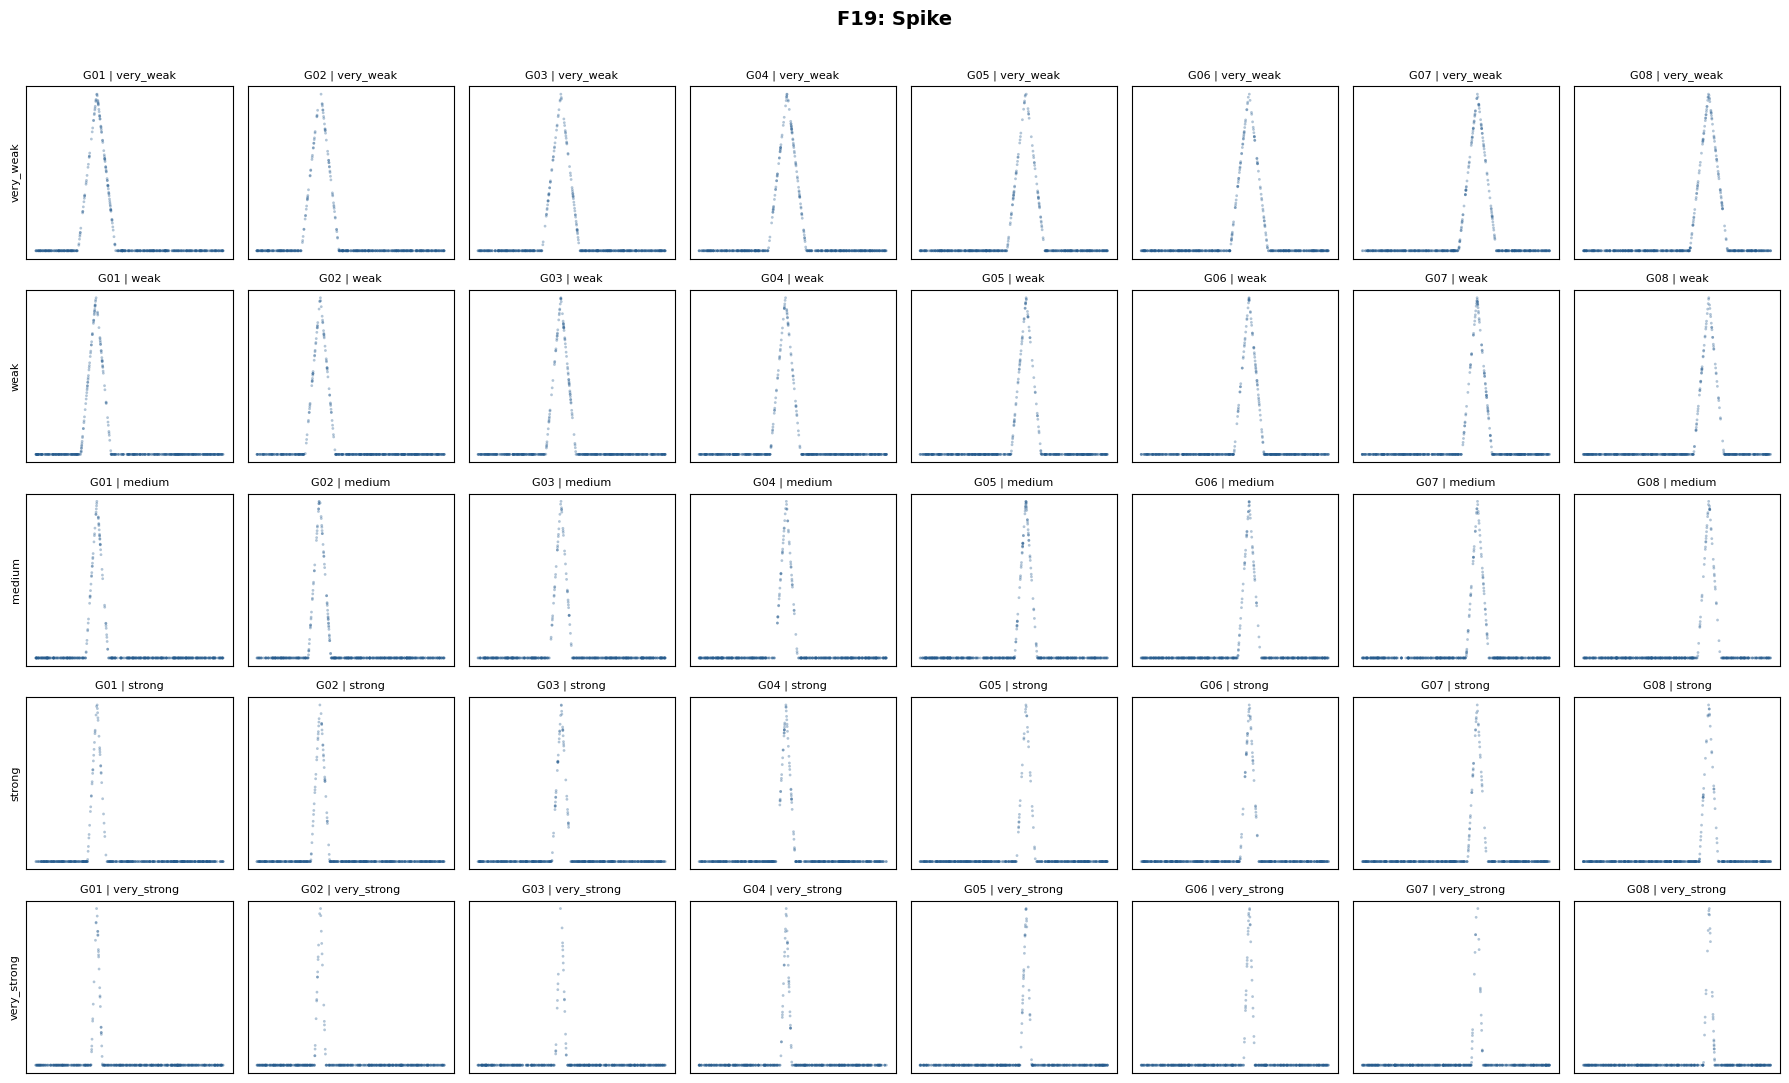

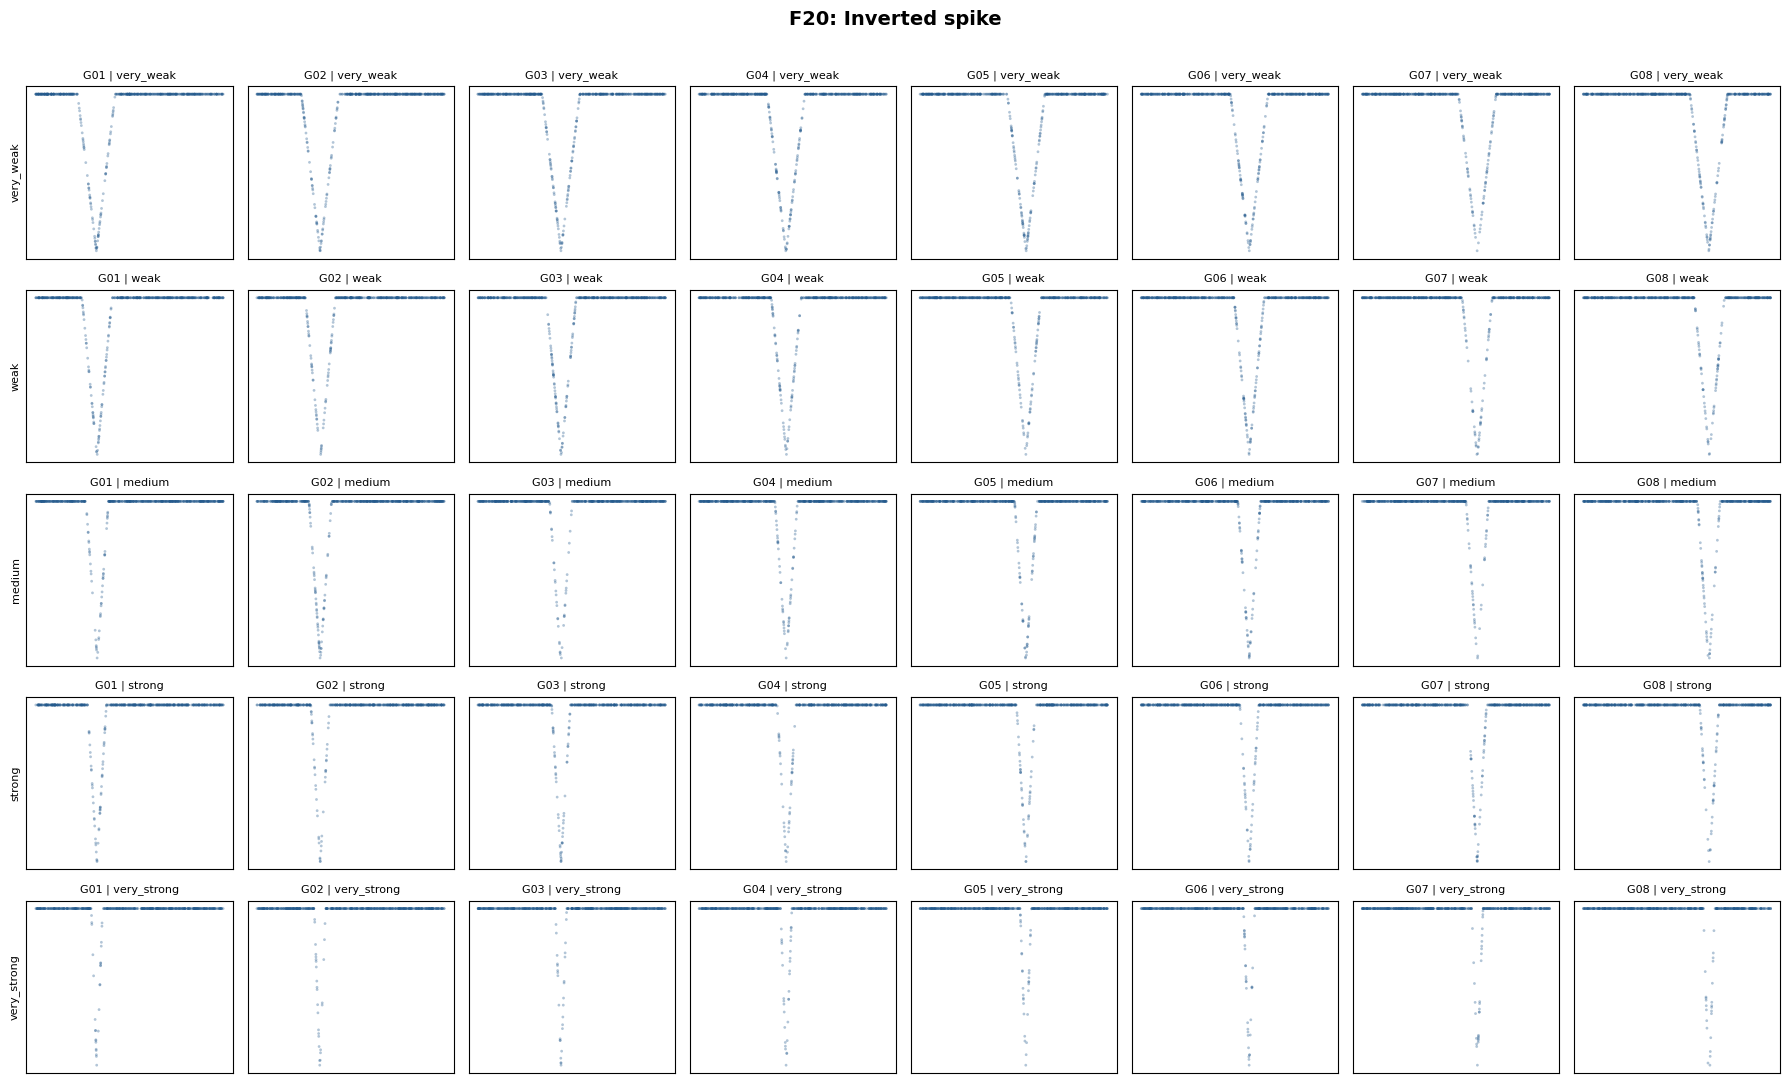

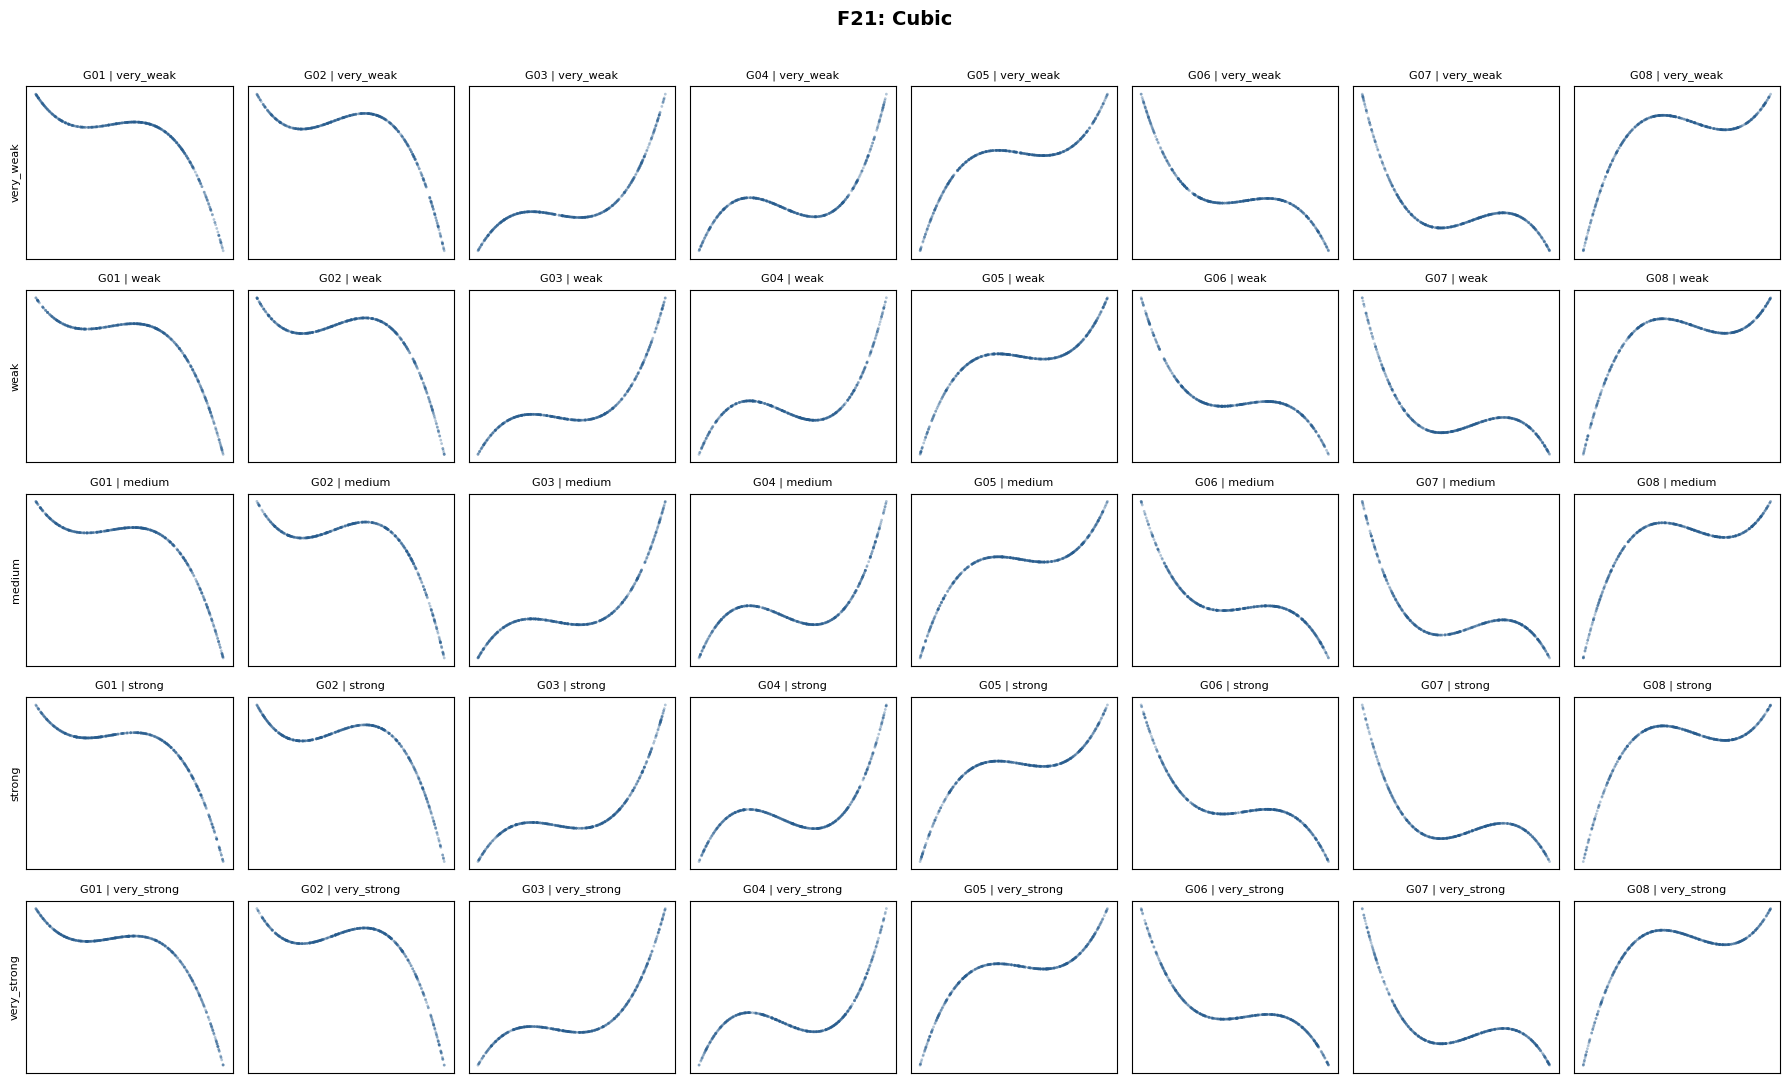

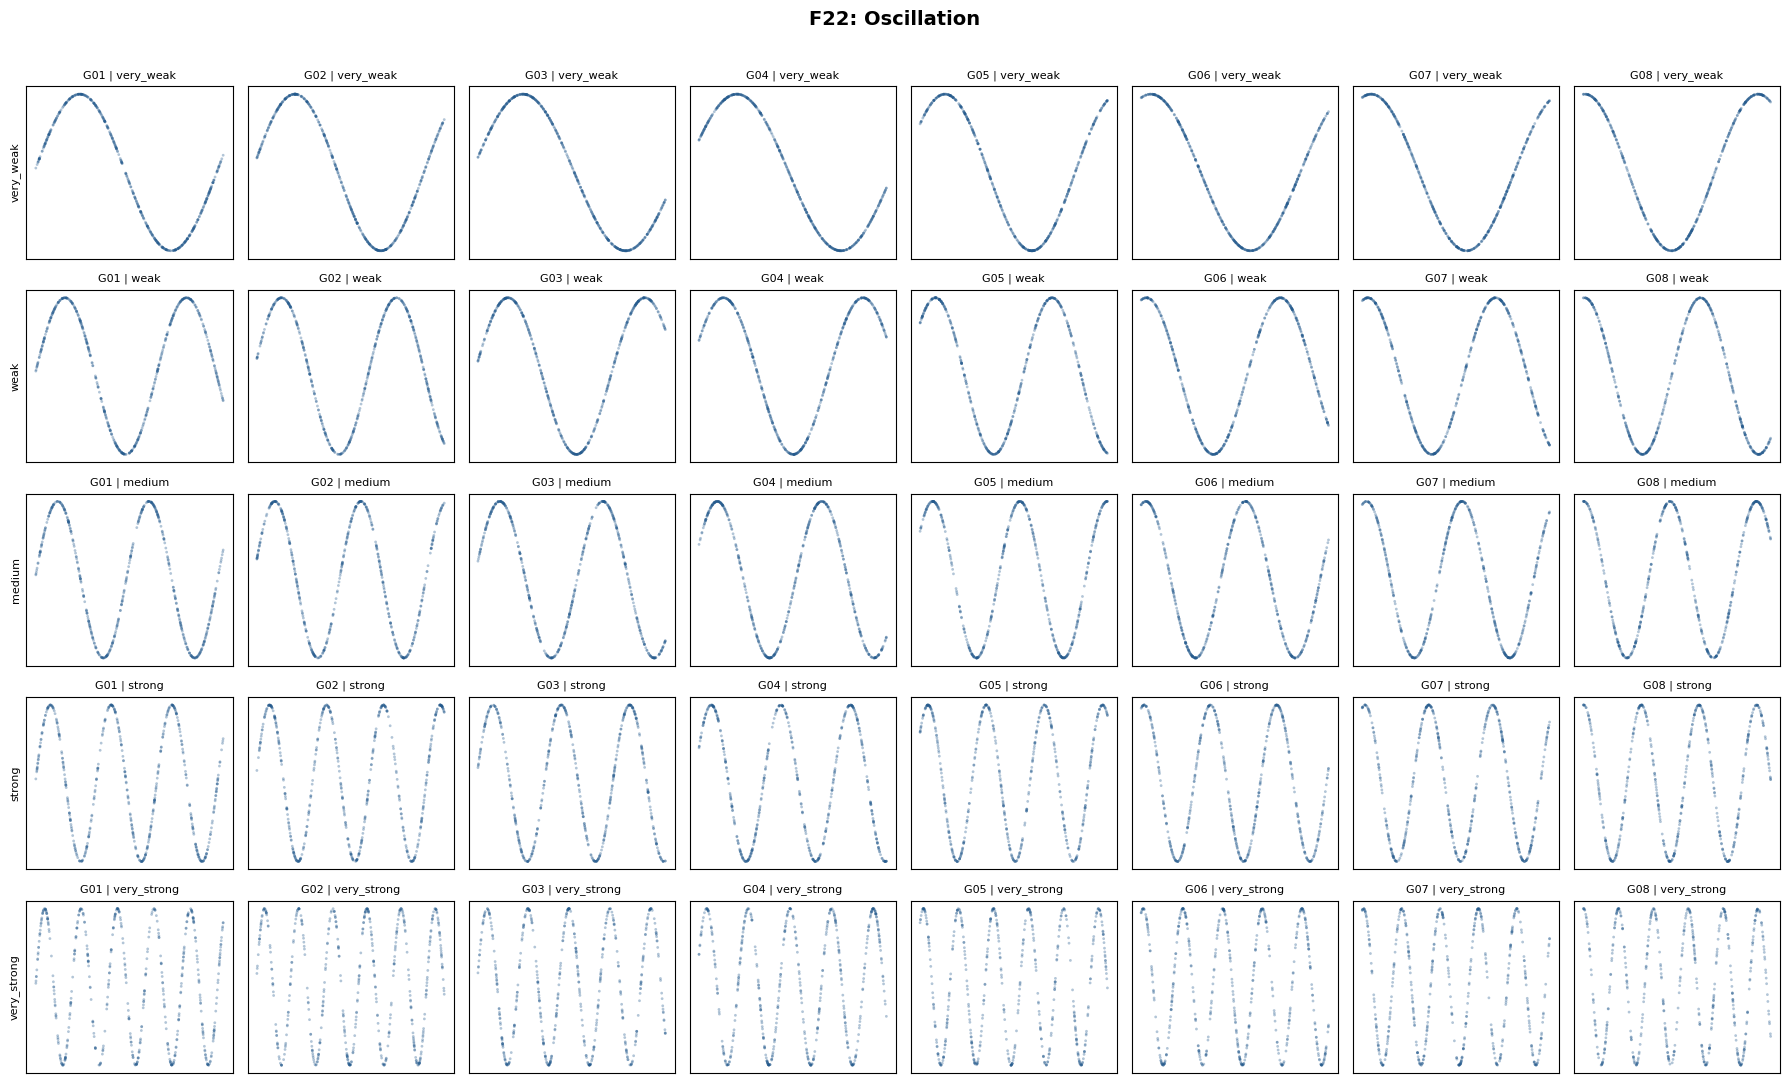

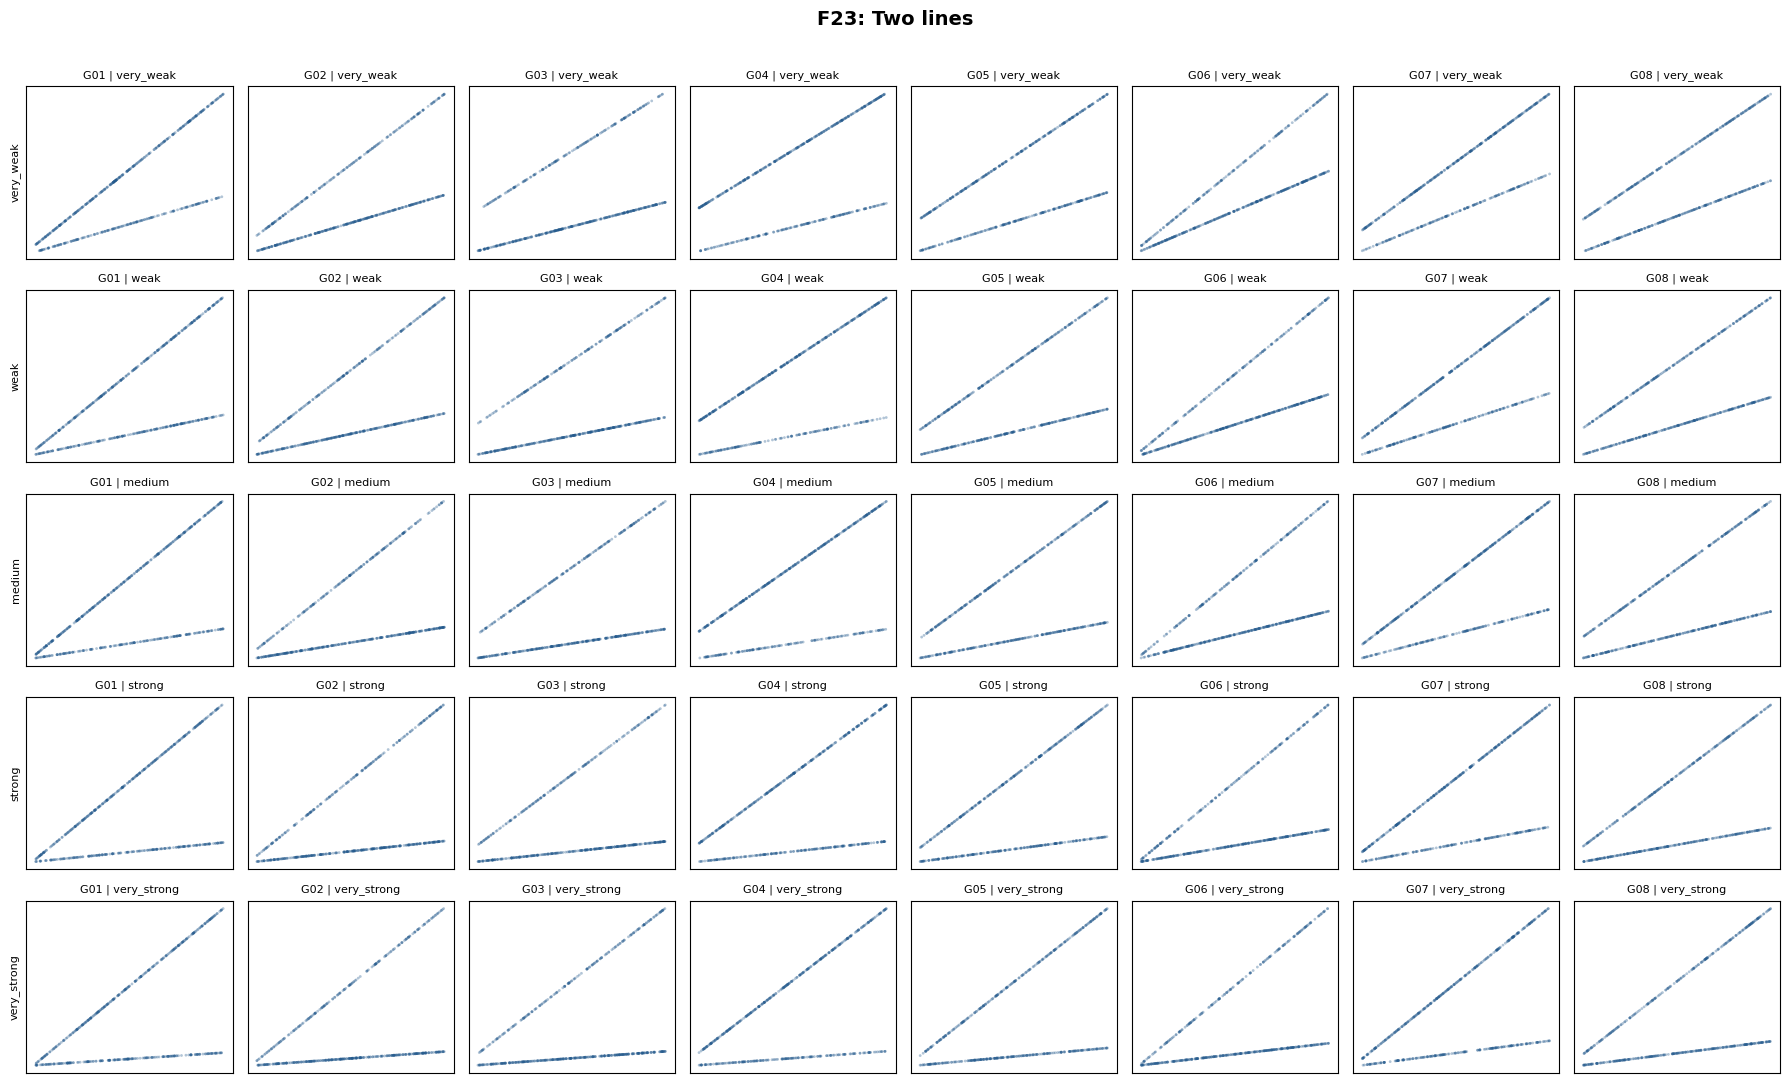

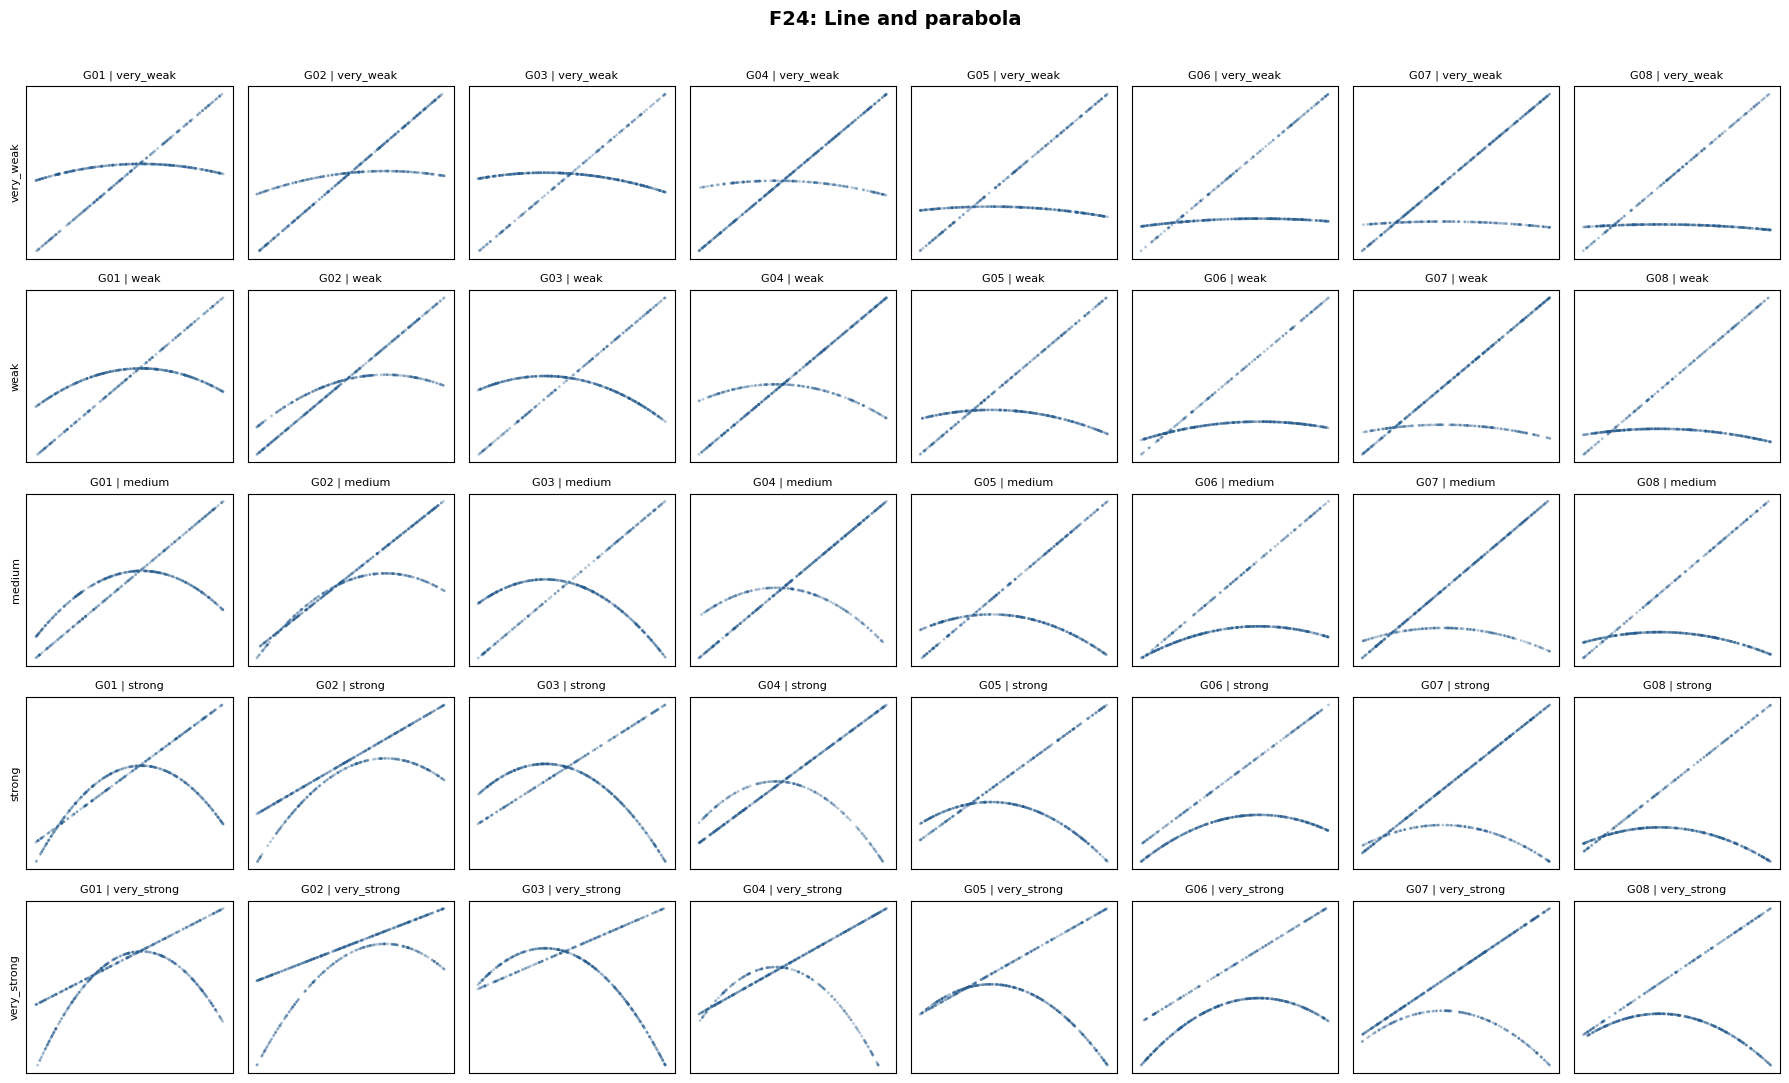

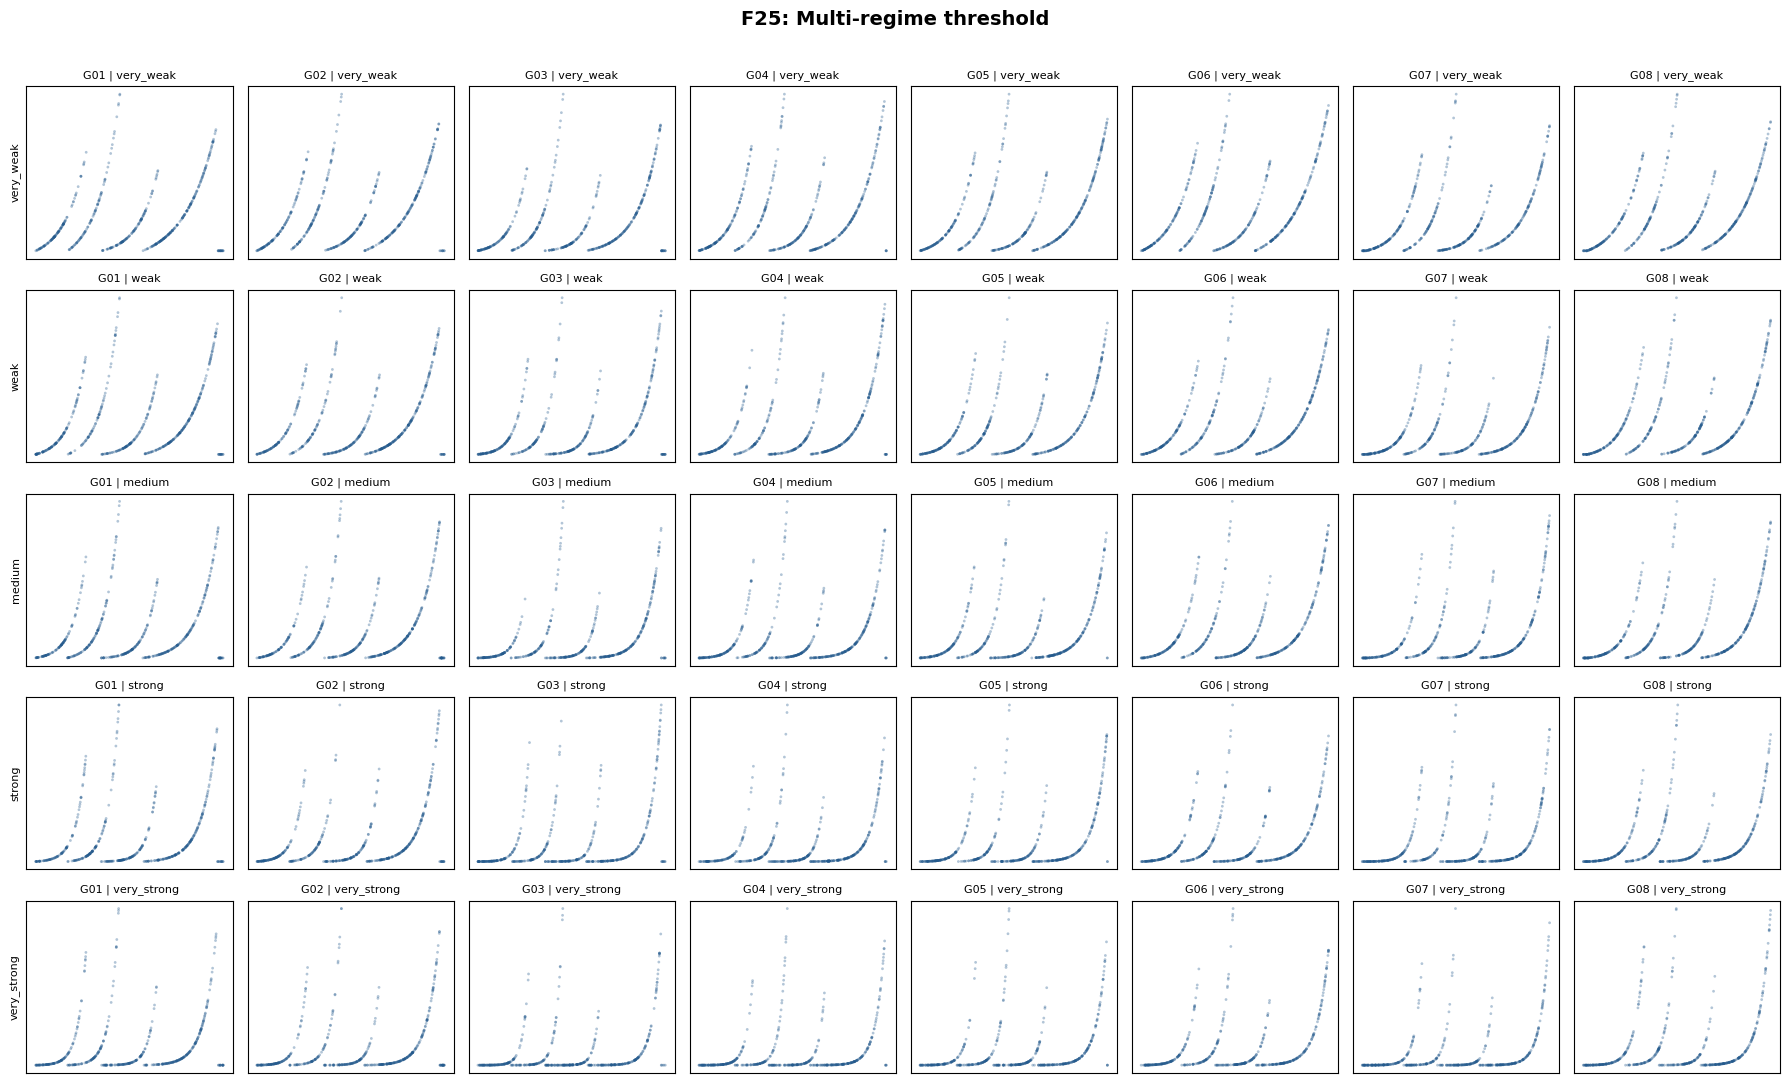

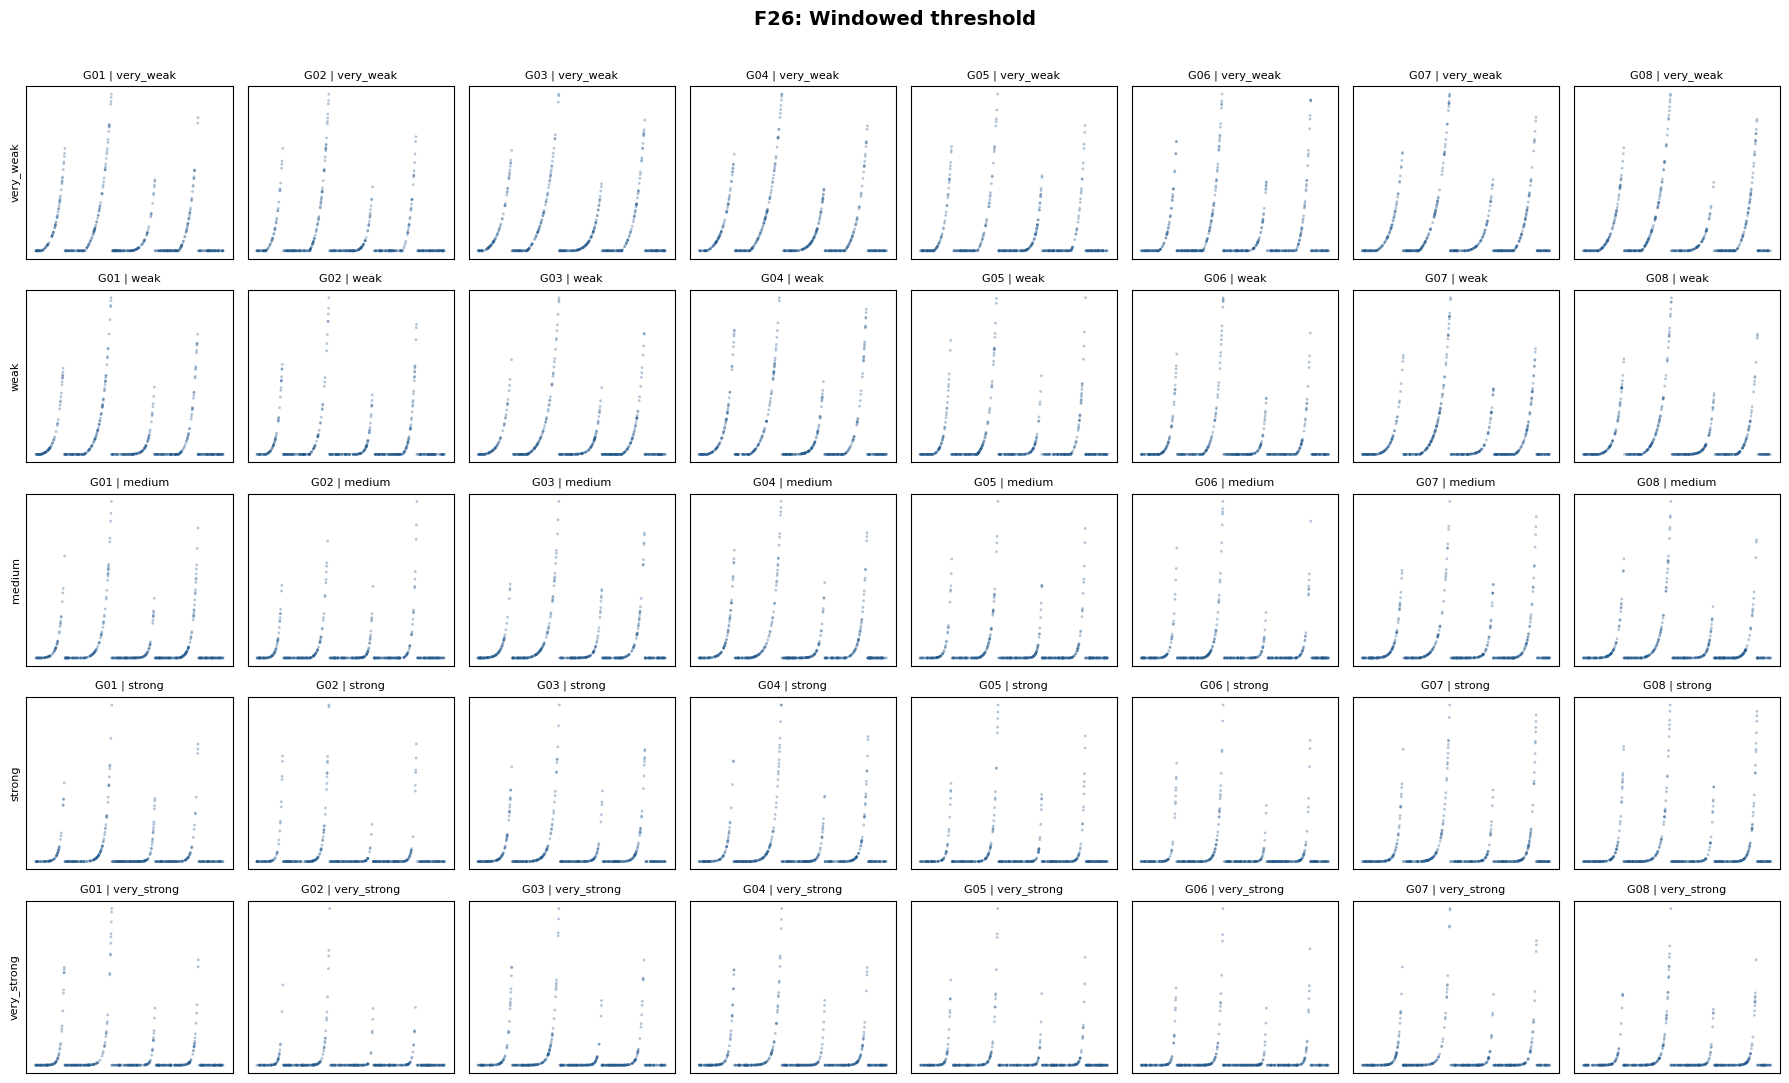

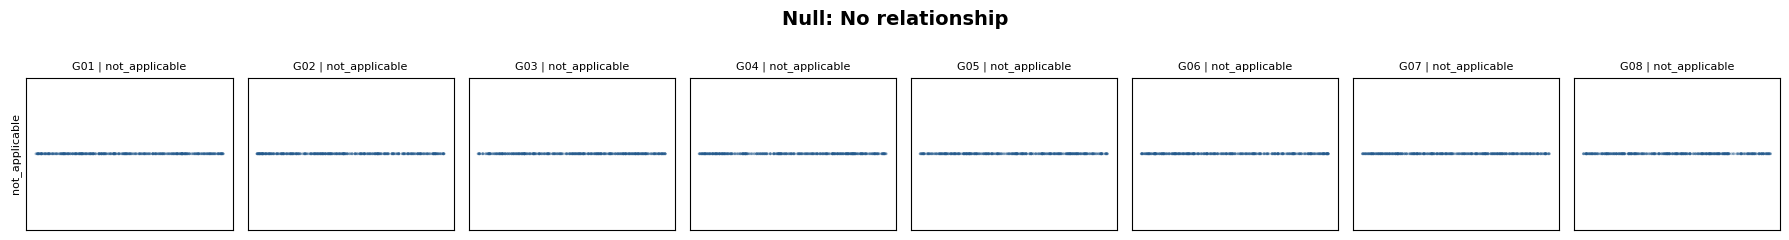

Saved 26 clean-review sheets to /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/F/output/S1_parameterized/review_clean_all_families


,family_id,family_name,figure_path
0,F01,Linear positive,/Users/mimi/Documents/Code/Github/GSA-work/exp...
1,F02,Linear negative,/Users/mimi/Documents/Code/Github/GSA-work/exp...
2,F03,Power convex positive,/Users/mimi/Documents/Code/Github/GSA-work/exp...
3,F04,Power convex negative,/Users/mimi/Documents/Code/Github/GSA-work/exp...
4,F05,Power concave positive,/Users/mimi/Documents/Code/Github/GSA-work/exp...
5,F06,Power concave negative,/Users/mimi/Documents/Code/Github/GSA-work/exp...
6,F07,Saturation positive,/Users/mimi/Documents/Code/Github/GSA-work/exp...
7,F08,Saturation negative,/Users/mimi/Documents/Code/Github/GSA-work/exp...
8,F09,Log positive,/Users/mimi/Documents/Code/Github/GSA-work/exp...
9,F10,Log negative,/Users/mimi/Documents/Code/Github/GSA-work/exp...


In [87]:
# Clean-review export controls for this step.
EXPORT_ALL_FAMILY_CLEAN_REVIEW = True
DISPLAY_ALL_FAMILY_CLEAN_REVIEW = True
CLEAN_REVIEW_DPI = 130
CLEAN_REVIEW_DIR = OUTPUT_ROOT / 'review_clean_all_families'

BASE_LOOKUP = {cfg.base_function_id: cfg for cfg in base_functions}


def plot_clean_family(family_id: str, groups: list[str] | None = None,
                      blind: bool = False, figsize=(18, 11)):
    selected = base_df[base_df['family_id'].eq(family_id)].copy()
    if groups is not None:
        selected = selected[selected['nuisance_group'].isin(groups)]
    groups_here = sorted(selected['nuisance_group'].unique())
    strengths_here = STRENGTH_NAMES if family_id != 'Null' else ['not_applicable']
    height = max(2.4, figsize[1] * len(strengths_here) / len(STRENGTH_NAMES))
    fig, axes = plt.subplots(
        len(strengths_here), len(groups_here),
        figsize=(figsize[0], height), squeeze=False,
    )
    x = np.linspace(0.0, 1.0, 500)
    for row_idx, strength_name in enumerate(strengths_here):
        for col_idx, group in enumerate(groups_here):
            ax = axes[row_idx, col_idx]
            match = selected[
                selected['strength_name'].eq(strength_name)
                & selected['nuisance_group'].eq(group)
            ].iloc[0]
            cfg = BASE_LOOKUP[int(match['base_function_id'])]
            rng = np.random.default_rng(RANDOM_SEED + cfg.base_function_id)
            xr = rng.uniform(0.0, 1.0, N_PER_CASE)
            branch_rng = rng if cfg.family_id in MULTI_BRANCH_FAMILIES else None
            yr = evaluate_signal(xr, cfg.family_id, cfg.params, branch_rng)
            ax.scatter(xr, yr, s=4, alpha=0.35, color='#245a8d', edgecolors='none')
            title = f'P{cfg.base_function_id:04d}' if blind else f'{group} | {strength_name}'
            ax.set_title(title, fontsize=8)
            ax.set_xticks([]); ax.set_yticks([])
            if col_idx == 0:
                ax.set_ylabel(strength_name, fontsize=8)
    heading = 'Blind clean review' if blind else f'{family_id}: {FAMILY_NAMES[family_id]}'
    fig.suptitle(heading, fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    return fig


# Manual Gate-1 visual boundaries agreed from the review panels.
# Below absent_snr: No relationship; absent_snr..clear_snr: Uncertain;
# at/above clear_snr: Relationship.
GLOBAL_SNR_LABEL_RULES = {
    'F07': {'absent_snr': 0.29, 'clear_snr': 1.0},
    'F25': {'absent_snr': 2.9, 'clear_snr': 10.0},
    'F26': {'absent_snr': 2.29, 'clear_snr': 10.0},
}


def clean_visual_codebook(row: pd.Series) -> dict[str, Any]:
    """Encode the clean-plot review; no noisy metric is used here."""
    fid = row['family_id']
    if fid == 'Null':
        return {'global': 0.0, 'simple': 0.0, 'monotonic': 0.0, 'linear': 0.0,
                'notes': 'Independent x and y; all relationship characteristics absent.'}

    # Global means that the relation is supported over a substantial analysis
    # range. The manually reviewed F07/F25/F26 families use explicit noisy-SNR
    # boundaries below, so their clean endpoint must be Relationship.
    if fid in GLOBAL_SNR_LABEL_RULES:
        global_label = 1.0
    elif fid in {'F19', 'F20'}:
        global_label = 0.0
    elif fid in {f'F{i:02d}' for i in range(3, 13)}:
        span = float(row['change_span_90'])
        global_label = 1.0 if span >= 0.60 else (0.5 if span >= 0.35 else 0.0)
    else:
        global_label = 1.0

    if fid in {f'F{i:02d}' for i in range(1, 13)}:
        simple_label = 1.0
    elif fid in {'F13', 'F14', 'F15', 'F16'}:
        simple_label = 0.5
    elif fid in {'F18', 'F21'}:
        if row['clean_line_r2'] >= 0.985 and row['monotonic_fraction'] >= 0.99:
            simple_label = 1.0
        elif row['clean_line_r2'] >= 0.93 or row['monotonic_fraction'] >= 0.90:
            simple_label = 0.5
        else:
            simple_label = 0.0
    else:
        simple_label = 0.0

    if fid in {f'F{i:02d}' for i in range(1, 15)}:
        monotonic_label = 1.0
    elif fid in {'F15', 'F16'}:
        monotonic_label = 0.5 if row['strength_index'] <= 1 else 0.0
    elif fid in {'F18', 'F21'}:
        fraction = float(row['monotonic_fraction'])
        monotonic_label = 1.0 if fraction >= 0.995 else (0.5 if fraction >= 0.90 else 0.0)
    else:
        monotonic_label = 0.0

    if fid in {'F01', 'F02'}:
        linear_label = 1.0
    elif fid in ({f'F{i:02d}' for i in range(3, 15)} | {'F18', 'F21'}):
        r2 = float(row['clean_line_r2'])
        linear_label = 1.0 if r2 >= 0.995 else (0.5 if r2 >= 0.97 else 0.0)
    else:
        linear_label = 0.0

    return {
        'global': global_label, 'simple': simple_label,
        'monotonic': monotonic_label, 'linear': linear_label,
        'notes': 'Visual codebook v1: clean geometry only; reviewed on 16 canonical 5x8 sheets.',
    }


clean_labels = base_df[[
    'base_function_id', 'family_id', 'canonical_family', 'nuisance_group',
    'strength_index', 'strength_name', 'active_change_fraction',
    'change_span_90', 'clean_line_r2', 'monotonic_fraction', 'saturation_x90',
]].copy()
review_rows = [clean_visual_codebook(row) for _, row in base_df.iterrows()]
for gate in ['global', 'simple', 'monotonic', 'linear']:
    clean_labels[f'{gate}_clean_label'] = [row[gate] for row in review_rows]
clean_labels['review_confidence'] = 'codebook_and_canonical_sheet'
clean_labels['review_notes'] = [row['notes'] for row in review_rows]


def visual_boundary_for(row: pd.Series, gate: str) -> dict[str, Any]:
    clean_label = float(row[f'{gate}_clean_label'])
    fid = row['family_id']
    if gate == 'global':
        if fid in GLOBAL_SNR_LABEL_RULES:
            rule = GLOBAL_SNR_LABEL_RULES[fid]
            clear = float(rule['clear_snr'])
            absent = float(rule['absent_snr'])
        else:
            clear = 3.0 if fid in {f'F{i:02d}' for i in range(1, 13)} else 5.0
            if fid in {'F23', 'F24'}:
                clear = 8.0
            absent = 0.3 if clear <= 5.0 else 1.0
        low = 0.0
    elif gate == 'simple':
        clear, absent, low = 3.0, 0.3, 0.5
    elif gate == 'monotonic':
        clear, absent, low = 5.0, 1.0, 0.5
    else:
        if clean_label == 0.0:
            r2 = float(row['clean_line_r2'])
            clear = 5.0 if r2 < 0.90 else (15.0 if r2 < 0.97 else 30.0)
        else:
            clear = 3.0
        absent, low = 1.0, 0.5
    if fid == 'Null':
        clear, absent, low = 0.0, 0.0, 0.0
    return {
        'base_function_id': int(row['base_function_id']),
        'gate': gate,
        'clean_label': clean_label,
        'clear_snr': clear,
        'absent_snr': absent,
        'low_snr_label': low,
        'review_notes': 'Boundaries from canonical pilot panels at SNR 100..0.01; no metric used.',
    }


snr_boundaries = pd.DataFrame([
    visual_boundary_for(row, gate)
    for _, row in clean_labels.iterrows()
    for gate in ['global', 'simple', 'monotonic', 'linear']
])

print(f'Clean labels completed: {len(clean_labels):,}')
print(f'Gate/SNR boundaries completed: {len(snr_boundaries):,}')
for gate in ['global', 'simple', 'monotonic', 'linear']:
    print(f'\n{gate.title()} clean-label distribution:')
    display(clean_labels[f'{gate}_clean_label'].value_counts().sort_index().rename('cases').to_frame())

if WRITE_DESIGN_TABLES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    parameter_groups.to_csv(OUTPUT_DIR / 'parameter_groups.csv', index=False)
    base_df.to_csv(OUTPUT_DIR / 'base_functions.csv', index=False)
    clean_labels.to_csv(OUTPUT_DIR / 'clean_visual_labels.csv', index=False)
    snr_boundaries.to_csv(OUTPUT_DIR / 'snr_visual_boundaries.csv', index=False)

if EXPORT_ALL_FAMILY_CLEAN_REVIEW:
    CLEAN_REVIEW_DIR.mkdir(parents=True, exist_ok=True)
    review_manifest = []
    for family_id in [*SIGNAL_FAMILIES, 'Null']:
        fig = plot_clean_family(family_id)
        figure_path = CLEAN_REVIEW_DIR / f'{family_id}_clean_review.png'
        fig.savefig(figure_path, dpi=CLEAN_REVIEW_DPI, bbox_inches='tight')
        review_manifest.append({
            'family_id': family_id,
            'family_name': FAMILY_NAMES[family_id],
            'figure_path': str(figure_path),
        })
        if DISPLAY_ALL_FAMILY_CLEAN_REVIEW:
            display(fig)
        plt.close(fig)
    review_manifest = pd.DataFrame(review_manifest)
    review_manifest.to_csv(CLEAN_REVIEW_DIR / 'figure_manifest.csv', index=False)
    print(f'Saved {len(review_manifest)} clean-review sheets to {CLEAN_REVIEW_DIR}')
    display(review_manifest)

## 6. Grouped development/test split and grouped validation

The initial split uses parameter geometry only. After clean visual labels are filled, rerun `assign_group_splits` with label profiles so Global/Uncertain/No Global proportions are also matched.

- Two nuisance groups are sealed as final test.
- The remaining six groups form development data.
- The six development groups are paired into three validation folds.
- For each fold: four groups train, two groups validate.
- After method selection: recalibrate on all six development groups and evaluate the two final-test groups once.

In [88]:
def _all_pairings(items: tuple[str, ...]):
    if not items:
        yield []
        return
    first = items[0]
    for i in range(1, len(items)):
        second = items[i]
        rest = items[1:i] + items[i+1:]
        for pairs in _all_pairings(rest):
            yield [(first, second)] + pairs


def assign_group_splits(groups: pd.DataFrame, label_profiles: pd.DataFrame | None = None) -> pd.DataFrame:
    rows = []
    for canonical, frame in groups.groupby('canonical_family', sort=True):
        frame = frame.sort_values('nuisance_group').reset_index(drop=True)
        ids = frame['nuisance_group'].tolist()

        # With a single group, no test split is possible.
        if len(ids) == 1:
            rows.append({
                'canonical_family': canonical,
                'nuisance_group': ids[0],
                'split_role': 'development',
                'validation_fold': 1,
            })
            continue

        x = frame[['u1', 'u2', 'u3']].to_numpy(float)
        overall_center = x.mean(axis=0)
        median_pair_distance = np.median([
            np.linalg.norm(x[i] - x[j]) for i, j in combinations(range(len(x)), 2)
        ])

        best_pair, best_score = None, np.inf
        for i, j in combinations(range(len(x)), 2):
            pair_center = (x[i] + x[j]) / 2.0
            score = np.linalg.norm(pair_center - overall_center)
            score += 0.25 * abs(np.linalg.norm(x[i] - x[j]) - median_pair_distance)
            if label_profiles is not None:
                prof = label_profiles[label_profiles['canonical_family'].eq(canonical)]
                if not prof.empty:
                    full = prof.drop(columns=['canonical_family', 'nuisance_group']).mean().to_numpy(float)
                    selected_prof = prof[prof['nuisance_group'].isin([ids[i], ids[j]])]
                    if len(selected_prof) == 2:
                        score += np.linalg.norm(selected_prof.drop(
                            columns=['canonical_family', 'nuisance_group']).mean().to_numpy(float) - full)
            if score < best_score:
                best_pair, best_score = (ids[i], ids[j]), score

        remaining = tuple(group for group in ids if group not in best_pair)
        lookup = frame.set_index('nuisance_group')[['u1', 'u2', 'u3']]
        best_matching, best_matching_score = None, np.inf
        for matching in _all_pairings(remaining):
            score = 0.0
            for left, right in matching:
                pair_center = (lookup.loc[left].to_numpy() + lookup.loc[right].to_numpy()) / 2.0
                score += np.linalg.norm(pair_center - overall_center) ** 2
                score -= 0.10 * np.linalg.norm(
                    lookup.loc[left].to_numpy() - lookup.loc[right].to_numpy())
            if score < best_matching_score:
                best_matching, best_matching_score = matching, score

        role_by_group = {group: ('test', 0) for group in best_pair}
        for fold, pair in enumerate(best_matching, start=1):
            for group in pair:
                role_by_group[group] = ('development', fold)
        for group in ids:
            role, fold = role_by_group[group]
            rows.append({
                'canonical_family': canonical,
                'nuisance_group': group,
                'split_role': role,
                'validation_fold': fold,
            })
    return pd.DataFrame(rows)


if USE_NUISANCE_GROUPS:
    split_label_profiles = clean_labels[[
        'canonical_family', 'nuisance_group', 'global_clean_label'
    ]].copy()
    split_label_profiles['global_yes'] = split_label_profiles['global_clean_label'].eq(1.0).astype(float)
    split_label_profiles['global_uncertain'] = split_label_profiles['global_clean_label'].eq(0.5).astype(float)
    split_label_profiles['global_no'] = split_label_profiles['global_clean_label'].eq(0.0).astype(float)
    split_label_profiles = split_label_profiles.groupby(
        ['canonical_family', 'nuisance_group'], as_index=False
    )[['global_yes', 'global_uncertain', 'global_no']].mean()
    group_splits = assign_group_splits(parameter_groups, split_label_profiles)
else:
    group_splits = assign_group_splits(parameter_groups, label_profiles=None)

base_df = base_df.merge(group_splits, on=['canonical_family', 'nuisance_group'], how='left', validate='many_to_one')

if USE_NUISANCE_GROUPS:
    assert base_df[base_df['family_id'].ne('Null')].groupby(['family_id', 'split_role']).size().unstack().eq(
        pd.Series({'development': 30, 'test': 10})
    ).all().all()

print('Base functions per family and split:')
display(base_df.groupby(['family_id', 'split_role']).size().unstack())
if 'validation_fold' in base_df.columns:
    dev = base_df[base_df['split_role'].eq('development')]
    if len(dev) > 0:
        print('Development validation-fold counts per family:')
        display(dev.groupby(['family_id', 'validation_fold']).size().unstack())

Base functions per family and split:


split_role,development,test
family_id,,
F01,30,10
F02,30,10
F03,30,10
F04,30,10
F05,30,10
F06,30,10
F07,30,10
F08,30,10
F09,30,10


Development validation-fold counts per family:


validation_fold,1,2,3
family_id,,,
F01,10,10,10
F02,10,10,10
F03,10,10,10
F04,10,10,10
F05,10,10,10
F06,10,10,10
F07,10,10,10
F08,10,10,10
F09,10,10,10


## 7. Case table and scatter generation

All families and all 227 SNR levels are generated in `full` mode.
Cases from representative families (F01, F03, F05, F07, F13, F15, F18, F21, F22, F23, F25, F26, Null)
are tagged with `is_representative=True` for downstream filtering.

All SNR values and replicates from one `base_function_id` share the same
clean signal; only the noise realization changes.

In [89]:
def sample_x(n: int, distribution: str, rng: np.random.Generator) -> np.ndarray:
    if distribution == 'even':
        return rng.uniform(0.0, 1.0, n)
    if distribution == 'left_dense':
        return rng.beta(2.0, 5.0, n)
    if distribution == 'right_dense':
        return rng.beta(5.0, 2.0, n)
    if distribution == 'center_dense':
        return rng.beta(5.0, 5.0, n)
    raise ValueError(distribution)


def unit_variance_noise(n: int, distribution: str, rng: np.random.Generator) -> np.ndarray:
    if distribution == 'normal':
        return rng.normal(size=n)
    if distribution == 'student_t5':
        return rng.standard_t(5, size=n) * math.sqrt(3.0 / 5.0)
    if distribution == 'uniform':
        return rng.uniform(-math.sqrt(3.0), math.sqrt(3.0), size=n)
    raise ValueError(distribution)


def signal_variance(cfg: BaseFunction, grid_size: int = 20_001) -> float:
    if cfg.family_id == 'Null':
        return 1.0
    if cfg.family_id in MULTI_BRANCH_FAMILIES:
        rng = np.random.default_rng(RANDOM_SEED + cfg.base_function_id)
        x = rng.uniform(0.0, 1.0, 100_000)
        y = evaluate_signal(x, cfg.family_id, cfg.params, rng)
    else:
        x = np.linspace(0.0, 1.0, grid_size)
        y = evaluate_signal(x, cfg.family_id, cfg.params)
    return float(np.var(y))


_variance_cache = {}


def generate_case_points(case: pd.Series) -> tuple[np.ndarray, np.ndarray]:
    cfg = BASE_LOOKUP[int(case['base_function_id'])]
    seed = RANDOM_SEED + int(case['case_id']) * 1009
    rng = np.random.default_rng(seed)
    x = sample_x(int(case['n']), str(case['x_distribution']), rng)
    branch_rng = rng if cfg.family_id in MULTI_BRANCH_FAMILIES else None
    y_signal = evaluate_signal(x, cfg.family_id, cfg.params, branch_rng)
    if cfg.family_id == 'Null':
        noise = unit_variance_noise(len(x), str(case['noise_distribution']), rng)
        scale = float(cfg.params.get('marginal_scale', 1.0))
        return x.astype(np.float32), (scale * noise).astype(np.float32)
    snr = float(case['snr_float'])
    if math.isinf(snr):
        sigma = 0.0
    else:
        variance = _variance_cache.setdefault(cfg.base_function_id, signal_variance(cfg))
        sigma = math.sqrt(max(variance, 1e-12) / snr)
    noise = unit_variance_noise(len(x), str(case['noise_distribution']), rng)
    y = y_signal + sigma * noise
    return x.astype(np.float32), y.astype(np.float32)


def build_cases() -> pd.DataFrame:
    if MODE == 'design':
        return pd.DataFrame()
    chosen = base_df.copy()

    rows = []
    for base in chosen.itertuples(index=False):
        for snr in SNR_GRID_FULL:
            for replicate in range(N_REPLICATES):
                rows.append({
                    'case_id': len(rows) + 1,
                    'base_function_id': int(base.base_function_id),
                    'family_id': base.family_id,
                    'family_name': base.family_name,
                    'canonical_family': base.canonical_family,
                    'nuisance_group': base.nuisance_group,
                    'strength_index': int(base.strength_index),
                    'strength_name': base.strength_name,
                    'params_json': base.params_json,
                    'split_role': base.split_role,
                    'validation_fold': int(base.validation_fold),
                    'snr': 'inf' if math.isinf(snr) else float(snr),
                    'snr_float': float(snr),
                    'replicate': replicate,
                    'n': N_PER_CASE,
                    'x_distribution': json.loads(base.params_json).get('x_distribution', 'even'),
                    'spread_pattern': 'constant',
                    'noise_distribution': json.loads(base.params_json).get('noise_distribution', 'normal'),
                    'is_representative': base.family_id in REPRESENTATIVE_FAMILIES,
                })
    return pd.DataFrame(rows)


cases_df = build_cases()
if cases_df.empty:
    print('Design mode: case generation skipped.')
else:
    print(f'Cases: {len(cases_df):,}')
    print(f'  Representative: {cases_df["is_representative"].sum():,}')
    print(f'  Other:          {(~cases_df["is_representative"]).sum():,}')
    display(cases_df.groupby(['family_id', 'is_representative']).size().unstack(fill_value=0))

if WRITE_CASE_TABLE and not cases_df.empty:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    cases_df.to_csv(OUTPUT_DIR / 'cases.csv', index=False)
    print(f'Saved: {OUTPUT_DIR / "cases.csv"}')

if WRITE_SCATTER_POINTS and not cases_df.empty:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    x_all = np.empty((len(cases_df), N_PER_CASE), dtype=np.float32)
    y_all = np.empty_like(x_all)
    t0 = time.time()
    for idx, (_, case) in enumerate(cases_df.iterrows()):
        x_all[idx], y_all[idx] = generate_case_points(case)
        if (idx + 1) % 5000 == 0:
            print(f'{idx + 1:,}/{len(cases_df):,} cases generated')
    np.savez_compressed(OUTPUT_DIR / 'scatter_points.npz', x=x_all, y=y_all)
    print(f'Saved points in {time.time() - t0:.1f}s')

Cases: 1,144,080
  Representative: 553,880
  Other:          590,200


is_representative,False,True
family_id,,
F01,0,45400
F02,45400,0
F03,0,45400
F04,45400,0
F05,0,45400
F06,45400,0
F07,0,45400
F08,45400,0
F09,45400,0


Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/F/output/S1_parameterized/cases.csv
5,000/1,144,080 cases generated
10,000/1,144,080 cases generated
15,000/1,144,080 cases generated
20,000/1,144,080 cases generated
25,000/1,144,080 cases generated
30,000/1,144,080 cases generated
35,000/1,144,080 cases generated
40,000/1,144,080 cases generated
45,000/1,144,080 cases generated
50,000/1,144,080 cases generated
55,000/1,144,080 cases generated
60,000/1,144,080 cases generated
65,000/1,144,080 cases generated
70,000/1,144,080 cases generated
75,000/1,144,080 cases generated
80,000/1,144,080 cases generated
85,000/1,144,080 cases generated
90,000/1,144,080 cases generated
95,000/1,144,080 cases generated
100,000/1,144,080 cases generated
105,000/1,144,080 cases generated
110,000/1,144,080 cases generated
115,000/1,144,080 cases generated
120,000/1,144,080 cases generated
125,000/1,144,080 cases generated
130,000/1,144,080 cases generated
135,000/1,144,080 cases generated

## 8. Noisy visual review and case labels

Use a coarse SNR grid first, review five plots at once after adaptive replicates are added, and record `clear_snr` and `absent_snr`. The boundary table is then expanded to case-level labels.

For Gate 1, low SNR can become `0` because no Global relationship is visually detectable. For later structural distinctions, low SNR usually becomes `0.5` when the distinction is hidden rather than contradicted.

In [90]:
def expand_boundary_labels(cases: pd.DataFrame, boundaries: pd.DataFrame,
                           clean_labels: pd.DataFrame) -> pd.DataFrame:
    labels = cases[['case_id', 'base_function_id', 'snr_float']].copy()
    for gate in ['global', 'simple', 'monotonic', 'linear']:
        boundary = boundaries[boundaries['gate'].eq(gate)][[
            'base_function_id', 'clear_snr', 'absent_snr', 'low_snr_label'
        ]]
        work = labels[['base_function_id', 'snr_float']].merge(
            clean_labels[['base_function_id', 'family_id', f'{gate}_clean_label']],
            on='base_function_id', how='left', validate='many_to_one',
        ).merge(boundary, on='base_function_id', how='left', validate='many_to_one')
        clean_value = work[f'{gate}_clean_label'].to_numpy(float)
        snr = work['snr_float'].to_numpy(float)
        out = np.full(len(work), 0.5, dtype=float)
        out[snr >= work['clear_snr'].to_numpy(float)] = clean_value[
            snr >= work['clear_snr'].to_numpy(float)]
        out[snr <= work['absent_snr'].to_numpy(float)] = work.loc[
            snr <= work['absent_snr'].to_numpy(float), 'low_snr_label'
        ].to_numpy(float)
        # A structurally local/no-global clean curve does not become Global by
        # adding noise. Null remains No at every later Gate as well.
        if gate == 'global':
            out[clean_value == 0.0] = 0.0
        out[work['family_id'].eq('Null').to_numpy()] = 0.0
        labels[f'label_{gate}'] = out
    return labels.drop(columns='snr_float')


def label_profiles_for_split(clean_labels: pd.DataFrame) -> pd.DataFrame:
    joined = base_df[['base_function_id', 'canonical_family', 'nuisance_group']].merge(
        clean_labels[['base_function_id', 'global_clean_label']],
        on='base_function_id', how='left', validate='one_to_one')
    joined['global_yes'] = joined['global_clean_label'].eq(1.0).astype(float)
    joined['global_uncertain'] = joined['global_clean_label'].eq(0.5).astype(float)
    joined['global_no'] = joined['global_clean_label'].eq(0.0).astype(float)
    return joined.groupby(['canonical_family', 'nuisance_group'], as_index=False)[
        ['global_yes', 'global_uncertain', 'global_no']
    ].mean()


if not cases_df.empty:
    case_labels = expand_boundary_labels(cases_df, snr_boundaries, clean_labels)
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    case_labels.to_csv(LABELS_PATH, index=False)
    print(f'Saved: {LABELS_PATH}')
    for gate in ['global', 'simple', 'monotonic', 'linear']:
        print(f'\n{gate.title()} noisy-label distribution:')
        display(case_labels[f'label_{gate}'].value_counts().sort_index().rename('cases').to_frame())
else:
    case_labels = pd.DataFrame()
    print('Design mode: noisy labels skipped.')

Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/F/output/S1_parameterized/case_visual_labels.csv

Global noisy-label distribution:


,cases
label_global,
0.0,591280
0.5,168900
1.0,383900



Simple noisy-label distribution:


,cases
label_simple,
0.0,198080
0.5,694000
1.0,252000



Monotonic noisy-label distribution:


,cases
label_monotonic,
0.0,206960
0.5,665520
1.0,271600



Linear noisy-label distribution:


,cases
label_linear,
0.0,353400
0.5,723480
1.0,67200


## 9. Execution record

Execution modes:

- `design` (default): build the parameter design, clean labels, split audit, and clean-review sheets.
- `full`: additionally generate all 227 SNR levels, all replicates, case metadata, scatter points, and case-level visual labels.

This notebook writes dataset artifacts only to `F/output/S1_parameterized`.
Metric computation is handled separately by `F_S2_metrics_computation.ipynb`.


In [92]:
# representative_mask = cases_df['is_representative'].to_numpy(bool)

# representative_cases = cases_df.loc[representative_mask].copy()
# representative_cases.to_csv(
#     OUTPUT_DIR / 'representative_cases.csv',
#     index=False,
# )

# np.savez_compressed(
#     OUTPUT_DIR / 'representative_scatter_points.npz',
#     x=x_all[representative_mask],
#     y=y_all[representative_mask],
# )


SELECTED_STRENGTH_NAMES = ['medium', 'strong', 'very_strong']

representative_mask = (
    cases_df['is_representative'].to_numpy(bool)
    & (
        cases_df['strength_name'].isin(SELECTED_STRENGTH_NAMES).to_numpy()
        | cases_df['family_id'].eq('Null').to_numpy()
    )
)

representative_cases = cases_df.loc[representative_mask].copy()

# 保留原始 case_id，确保能与完整数据关联
representative_cases.to_csv(
    OUTPUT_DIR / 'representative_cases.csv',
    index=False,
)

np.savez_compressed(
    OUTPUT_DIR / 'representative_scatter_points.npz',
    x=x_all[representative_mask],
    y=y_all[representative_mask],
)

print(
    f'Saved representative subset: '
    f'{len(representative_cases):,} cases × {x_all.shape[1]} points'
)

print('\nFamily/strength breakdown:')
print(
    representative_cases
    .groupby(['family_id', 'strength_name'])
    .size()
    .to_string()
)

Saved representative subset: 335,960 cases × 500 points

Family/strength breakdown:
family_id  strength_name 
F01        medium            9080
           strong            9080
           very_strong       9080
F03        medium            9080
           strong            9080
           very_strong       9080
F05        medium            9080
           strong            9080
           very_strong       9080
F07        medium            9080
           strong            9080
           very_strong       9080
F13        medium            9080
           strong            9080
           very_strong       9080
F15        medium            9080
           strong            9080
           very_strong       9080
F18        medium            9080
           strong            9080
           very_strong       9080
F21        medium            9080
           strong            9080
           very_strong       9080
F22        medium            9080
           strong            9080
      